#**M3 Phase: Unsupervised Machine Learning for Grant Description and Integrated Sub-Topic Analysis**

**US Government Grant Opportunities Dataset**

By: Maggie Croghan Team 11

##**Domain Question**

How can clustering grant descriptions uncover meaningful sub-topic categories beyond broad classifications, and what do these finer-grained categories reveal about patterns of funding concentration, gaps, and potentially underserved areas within the grant landscape?

*Based on and modified from question 3 in M1*

##**Problem Statement**

This analysis dives into grant descriptions (from the *grant_opportunities_details* dataset) to discover the sub-domains within the broader categories and offer greater insight into what grants in these categories are actually serving. Each category is clustered independently and uses grant descriptions as the sole input. This analysis focuses on the five categories with the most grants to ensure each model has sufficient data points for clustering. Initial EDA revealed that the top categories, in order, were Health, Science, Education, Other, and Environment.

The domain question was reframed to specify the precise description characteristics this analysis would target. The characteristic of subject matter was chosen for the value it could provide to funding agencies who may be interested in diversifying their grants or to adovacy groups interested in the underserved groups within grant funding. Description complexity was also considered as characteristic for analysis, but initial EDA revealed more intriguing patterns within subject matter.



# **Data Import and Initial Cleaning**

In [ ]:
import pandas as pd
import numpy as np
import re

# IMPORT DATA
grants = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv",
    low_memory=False
)

details = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv",
    low_memory=False
)


# CLEAN COLUMN NAMES
def clean_names(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(r"[^\w]", "", regex=True)
    )
    return df

grants = clean_names(grants)
details = clean_names(details)


# CLEAN DATE COLUMNS
date_cols = [col for col in details.columns if "date" in col]

for col in date_cols:
    details[col] = pd.to_datetime(
        details[col],
        errors="coerce"
    )


# ENSURE BOOLEAN TYPE FOR ELIGIBILITY COLUMNS
eligibility_cols = [
    "eligibility_individuals",
    "eligibility_state_governments",
    "eligibility_county_governments",
    "eligibility_independent_school_districts",
    "eligibility_city_or_township_governments",
    "eligibility_special_district_governments",
    "eligibility_native_american_tribal_governments_federally_recognized",
    "eligibility_native_american_tribal_organizations_other",
    "eligibility_nonprofits_501c3",
    "eligibility_nonprofits_non_501c3",
    "eligibility_for_profit",
    "eligibility_small_businesses",
    "eligibility_private_institutions_of_higher_education",
    "eligibility_public_institutions_of_higher_education",
    "eligibility_public_indian_housing_authorities",
    "eligibility_others",
    "eligibility_unrestricted"
]

for col in eligibility_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR FUNDING INSTRUMENT TYPES
funding_cols = [
    "funding_cooperative_agreement",
    "funding_grant",
    "funding_procurement_contract",
    "funding_other"
]

for col in funding_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR ALL CATEGORY COLUMNS
category_cols = [
    "category_agriculture",
    "category_arts",
    "category_business",
    "category_community_development",
    "category_consumer_protection",
    "category_disaster",
    "category_education",
    "category_employment",
    "category_energy",
    "category_environment",
    "category_food",
    "category_health",
    "category_housing",
    "category_humanities",
    "category_iija",
    "category_income_security",
    "category_info",
    "category_law",
    "category_natural_resources",
    "category_opportunity_zone",
    "category_regional_development",
    "category_science",
    "category_transportation",
    "category_other"
]

for col in category_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)

# CLEAN NUMERIC COLUMNS
numeric_cols = [
    "estimated_total_program_funding",
    "award_ceiling",
    "award_floor",
    "expected_number_of_awards"
]

for col in numeric_cols:
    if col in details.columns:
        details[col] = (
            details[col]
            .astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
        )
        details[col] = pd.to_numeric(
            details[col],
            errors="coerce"
        )


# Fill missing descriptions
details['description'] = details['description'].fillna(details['funding_opportunity_title'])

# Create a single 'official_category' label by finding the first True category column
cat_cols = [c for c in details.columns if c.startswith('category_') and c != 'category_explanation']
details['official_category'] = details[cat_cols].idxmax(axis=1).str.replace('category_', '')

print("Grants shape:", grants.shape)
print("Details shape:", details.shape)

print("\nCategory columns:", len(category_cols))

details.head()

Grants shape: (74669, 17)
Details shape: (2000, 69)

Category columns: 24


,opportunity_id,funding_opportunity_number,funding_opportunity_title,opportunity_category,opportunity_category_explanation,expected_number_of_awards,cost_sharing_or_matching_requirement,version,posted_date,last_updated_date,...,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other,category_explanation,official_category
0,40112,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
1,40113,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
2,42048,FWS-R4-FLEXFUND,Southeast Region Flex Funds,Discretionary,NaN,25.0,False,3,2008-06-17,2008-06-18,...,False,False,True,False,False,False,False,False,NaN,natural_resources
3,42423,306-08-027-RFI,Alternative Development Program,Discretionary,NaN,1.0,False,1,2008-07-22,2008-07-22,...,False,False,False,False,False,False,False,False,NaN,agriculture
4,45657,04-563,Developing Country Collaborations in Plant Gen...,Discretionary,NaN,NaN,True,2,2004-03-22,2009-03-03,...,False,False,False,False,False,True,False,False,NaN,science


In [ ]:
details['estimated_total_program_funding'].isna().sum()

np.int64(1315)

In [ ]:
# details['estimated_total_program_funding'] = details['estimated_total_program_funding'].fillna(0)

In [ ]:
# count of duplicate rows
details['description'].duplicated().sum()

np.int64(126)

In [ ]:
details = details.drop_duplicates(subset="description")

In [ ]:
details['official_category'].value_counts()

,count
official_category,
health,556
science,423
education,397
other,106
environment,92
energy,51
food,47
natural_resources,39
agriculture,25


In [ ]:
# CLEAN TEXT COLUMNS
text_cols = [
    "description",
    "category_explanation",
    "additional_information_on_eligibility",
    "funding_opportunity_title"
]

for col in text_cols:
    if col in details.columns:
        details[col] = details[col].astype(str).str.strip()
        details[col] = details[col].str.lower()
        details[col] = details[col].apply(lambda x: re.sub(r"\s+", " ", x))  # remove whitespace
        details[col] = details[col].apply(lambda x: re.sub(r"[^\w\s]", "", x)) # remove special characters
        details[col] = details[col].apply(lambda x: re.sub(r"http\S+", " ", x)) # remove URLs
        details[col] = details[col].apply(lambda x: re.sub(r"\bu\.s\.\b", "us", x)) # normalize key grant terms


#**Unsupervised Machine Learning**

## **Health Category Clustering**

### **Create Health DataFrame**

In [ ]:
details_health = details[details['official_category'] == 'health']
details_health.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,556.000000,62.000000,556.000000,556,556,551,550,531,5.900000e+01,2.600000e+02,6.400000e+01
mean,339549.805755,21.596774,1.480216,2022-05-25 16:13:48.776978432,2022-08-07 22:52:39.712230144,2024-09-01 16:25:15.789473792,2024-10-20 00:54:58.909091072,2024-12-20 23:22:02.033898240,5.300452e+07,8.816649e+06,2.348594e+06
min,58617.000000,0.000000,1.000000,2010-11-01 00:00:00,2012-01-27 00:00:00,2011-04-15 00:00:00,2018-06-15 00:00:00,2023-10-29 00:00:00,5.000000e+05,0.000000e+00,0.000000e+00
25%,335008.750000,4.000000,1.000000,2021-09-07 06:00:00,2021-11-26 12:00:00,2023-11-28 12:00:00,2023-12-05 06:00:00,2024-02-12 00:00:00,3.800000e+06,2.500000e+05,0.000000e+00
50%,343952.500000,10.000000,1.000000,2022-10-27 00:00:00,2023-01-10 12:00:00,2024-06-21 00:00:00,2024-07-11 00:00:00,2024-08-22 00:00:00,1.536500e+07,4.000000e+05,0.000000e+00
75%,348324.250000,26.500000,1.000000,2023-06-02 00:00:00,2023-06-28 00:00:00,2025-05-25 00:00:00,2025-05-27 12:00:00,2025-07-12 00:00:00,6.415000e+07,1.000000e+06,1.500000e+05
max,350383.000000,113.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2031-12-06 00:00:00,2029-12-31 00:00:00,2040-01-01 00:00:00,5.000000e+08,5.000000e+08,7.300000e+07
std,20541.618105,26.096580,1.589823,NaN,NaN,NaN,NaN,NaN,9.404727e+07,4.336966e+07,9.968082e+06


### **Text Embedding**


In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [ ]:
embeddings_health = embedding_model.encode(
    details_health["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
)

embeddings_health = np.asarray(embeddings_health, dtype=np.float32)

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
import umap

umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_health_umap = umap_model.fit_transform(embeddings_health)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Grant descriptions were converted into numerical representations using a Sentence Transformer embedding model, which encodes each description into a dense vector capturing its semantic meaning rather than relying on keyword frequency alone. This approach enables clustering based on conceptual similarity between grants. To improve clustering efficiency and structure, Uniform Manifold Approximation and Projection (UMAP) was applied to reduce the high-dimensional embeddings into a lower-dimensional space while preserving their semantic relationships. The resulting vectors provide a compact, information-rich representation that supports accurate identification of sub-topic clusters within grant descriptions.

### **K-Means Clustering**

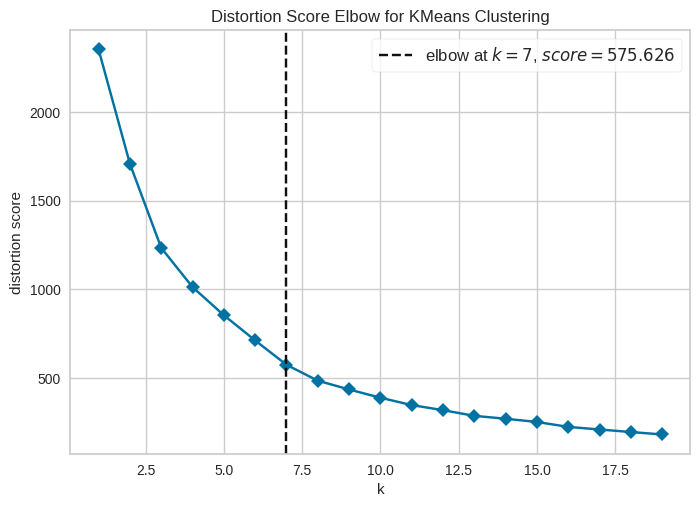

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(
    init="k-means++", # new
    n_init=10,      # increase iterations
    max_iter=500,   # new -- ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 20),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_health_umap)
visualizer.show()

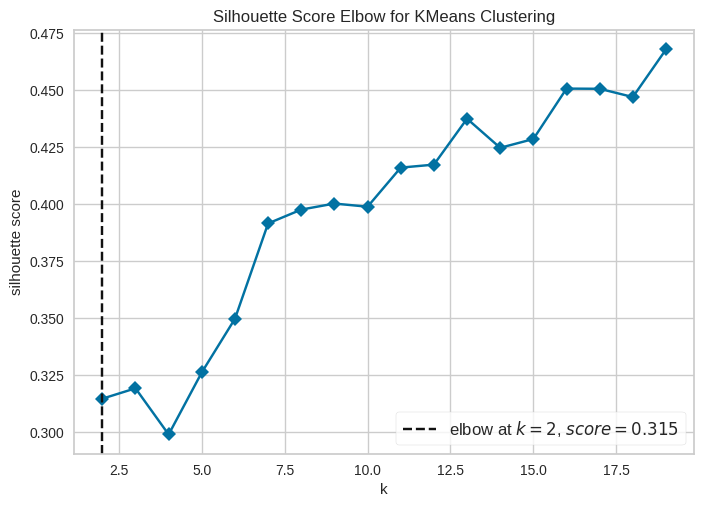

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 20),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_health_umap)
visualizer.show()

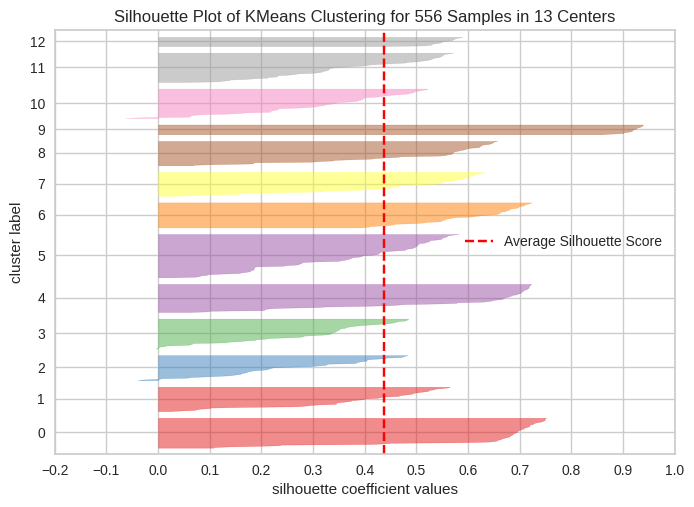

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 556 Samples in 13 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(
    n_clusters=13,
    init="k-means++", # new
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_health_umap)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [ ]:
# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_health['cluster_labels'] = kmeans_model.fit_predict(embeddings_health_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_health['cluster_labels'].value_counts())


cluster_labels
5     72
3     50
0     50
10    49
11    49
4     47
6     42
2     42
1     41
8     41
7     40
9     17
12    16
Name: count, dtype: int64


/tmp/ipython-input-65247215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health['cluster_labels'] = kmeans_model.fit_predict(embeddings_health_umap).astype(str)


**Updates**

The number of clusters chosen was updated from 7 clusters to 12 clusters. This provides a higher average silhoutte score and lower distortion score than in M2, while maintaining sufficiently sized clusters. It also created more descriptive clusters that better inform what grants in the health category actually address.

### **Extracting Key Words from Each Cluster**

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

GRANT_STOPWORDS = [
    "grant", "grants",
    "funding", "funded",
    "proposal", "proposals",
    "applicant", "applicants",
    "application", "applications",
    "funding opportunity",
    "funding opportunity announcement",
    "opportunity announcement",
    "announcement",
    "program", "programs",
    "submit", "submission", "submitted",
    "eligible", "eligibility",
    "agency", "federal",
    "foa", "nofo", "cfda",
    "opportunity", "health"
]

custom_stopwords = list(ENGLISH_STOP_WORDS.union(GRANT_STOPWORDS))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_features=1000,
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.85
)

phrase_vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_features=1000,
    ngram_range=(2,3),
    min_df=5,
    max_df=0.85
)

word_tfidf = word_vectorizer.fit_transform(details_health['description'])
word_terms = word_vectorizer.get_feature_names_out()

phrase_tfidf = phrase_vectorizer.fit_transform(details_health['description'])
phrase_terms = phrase_vectorizer.get_feature_names_out()


In [ ]:
def get_cluster_tfidf_summary(cluster_num, top_n=5):

    cluster_mask = (details_health['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:top_n]

    top_words = [
        (word_terms[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:top_n]

    top_phrases = [
        (phrase_terms[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    return top_words, top_phrases

In [ ]:
num_clusters = details_health['cluster_labels'].nunique()

for cluster_num in range(num_clusters):

    words, phrases = get_cluster_tfidf_summary(cluster_num, top_n=5)

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")



========== Cluster 0 ==========

Top Words:
research             0.1745
trial                0.1332
clinical             0.1264
independent          0.1168
career               0.115

Top Phrases:
clinical trial                 0.1337
career development             0.0615
independent research           0.0573
career transition              0.0527
independent clinical trial     0.0524

========== Cluster 1 ==========

Top Words:
research             0.108
hiv                  0.0988
immune               0.0732
animal               0.0568
models               0.0528

Top Phrases:
purpose support                0.0821
animal models                  0.0679
research projects              0.0594
purpose provide                0.0565
hiv prevention                 0.0508

========== Cluster 2 ==========

Top Words:
alcohol              0.0696
neural               0.0659
development          0.0577
clinical             0.0515
disorders            0.0491

Top Phrases:
mental disorders         

**Health Sub-Topics**

0: Independent Research & Career Development

1: HIV

2: Alcohol Use Disorders & Mental Disorders

3: Biomedical and Genome Research

4: International Aid

5: Alzheimers & Dementia

6: Occupational Safety

7: Common Fund

8: Mental Services and Experimental Interventions

9: Research Education

10: Translational Science

11: Small Business Concerns

12: Clinical Trials


### **Cluster Analysis**

In [ ]:
#assign sub-topic names to grants in details_health
cluster_name_mapping = {
    '0': 'Independent Research & Career Development',
    '1': 'HIV',
    '2': 'Alcohol Use Disorders & Mental Disorders',
    '3': 'Biomedical and Genome Research',
    '4': 'International Aid',
    '5': 'Alzheimers & Dementia',
    '6': 'Occupational Safety',
    '7': 'Common Fund',
    '8': 'Mental Services and Experimental Interventions',
    '9': 'Research Education',
    '10': 'Translational Science',
    '11': 'Small Business Concerns',
    '12': 'Clinical Trials'
}

if 'cluster_labels' not in details_health.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_health['cluster_labels'] = details_health['cluster_labels'].map(cluster_name_mapping)


/tmp/ipython-input-1832142833.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_health['cluster_labels'] = details_health['cluster_labels'].map(cluster_name_mapping)


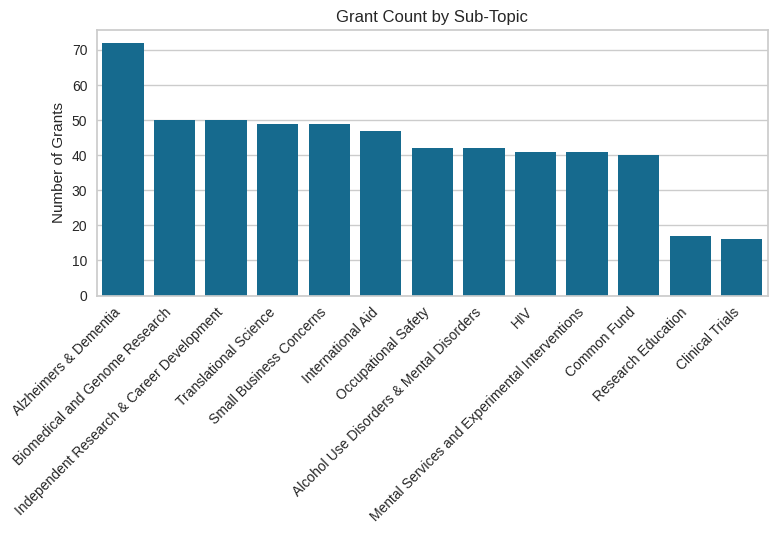

In [ ]:
import seaborn as sns

#sub-topic count bar chart

sns.countplot(data=details_health, x='cluster_labels', order=details_health['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

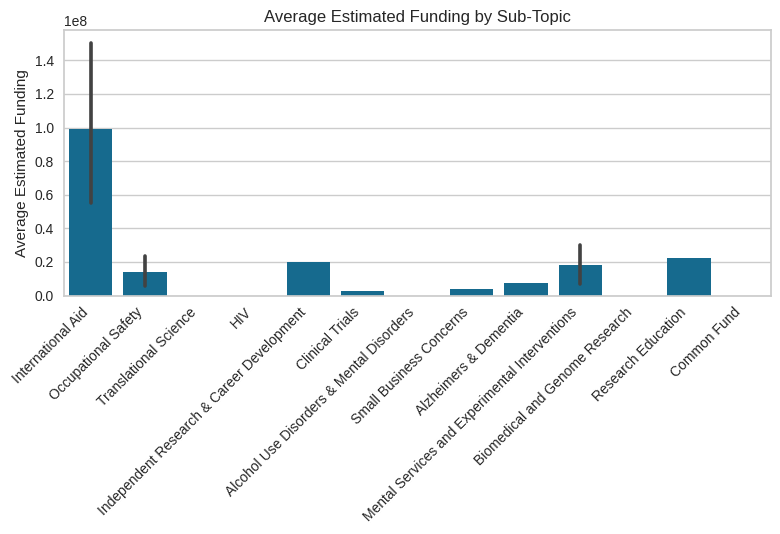

In [ ]:
#sub-topic by average estimated funding
sns.barplot(data=details_health, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#sub-topic by total estimated funding across all grants in the sub-topic

total_funding = pd.DataFrame(details_health.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_funding.sort_values(by='estimated_total_program_funding', ascending=False)

,estimated_total_program_funding
cluster_labels,
International Aid,2.677133e+09
Occupational Safety,3.367340e+08
Independent Research & Career Development,4.000000e+07
Mental Services and Experimental Interventions,3.690000e+07
Research Education,2.250000e+07
Alzheimers & Dementia,7.500000e+06
Small Business Concerns,4.000000e+06
Clinical Trials,2.500000e+06
Alcohol Use Disorders & Mental Disorders,0.000000e+00


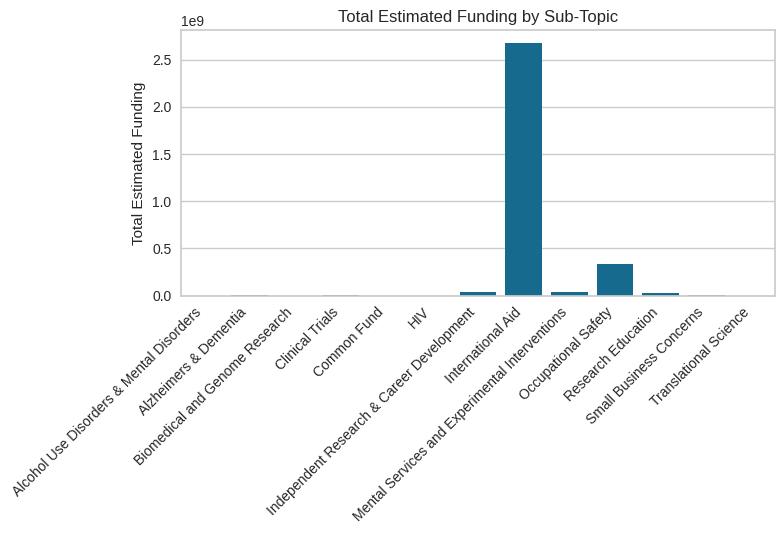

In [ ]:
sns.barplot(data=total_funding, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Science Category Clustering**

### **Create Science DataFrame**

In [ ]:
details_science= details[details['official_category'] == 'science']
details_science.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,423.000000,220.000000,423.000000,423,423,319,316,306,2.810000e+02,1.420000e+02,1.560000e+02
mean,332149.286052,4618.150000,4.943262,2021-11-12 20:05:06.382978560,2023-03-12 12:11:54.893616896,2023-02-03 22:34:13.918495232,2024-04-01 20:12:09.113924096,2026-02-24 18:58:49.411764736,4.178948e+07,3.260322e+07,8.424234e+06
min,45657.000000,0.000000,1.000000,2004-03-22 00:00:00,2009-03-03 00:00:00,2009-07-15 00:00:00,2023-09-27 00:00:00,2023-10-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,335522.000000,6.000000,1.000000,2021-09-01 12:00:00,2023-05-19 00:00:00,2023-01-10 12:00:00,2023-10-30 00:00:00,2023-12-16 06:00:00,4.400000e+06,3.625000e+05,5.000000e+03
50%,345092.000000,17.500000,3.000000,2022-12-23 00:00:00,2023-05-20 00:00:00,2023-09-29 00:00:00,2023-12-16 12:00:00,2025-01-05 00:00:00,9.400000e+06,1.200000e+06,1.000000e+05
75%,348286.500000,40.000000,6.000000,2023-05-22 00:00:00,2023-08-10 00:00:00,2023-11-30 00:00:00,2024-03-14 06:00:00,2027-03-21 18:00:00,2.000000e+07,5.000000e+06,5.000000e+05
max,350369.000000,999999.000000,62.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2043-05-10 00:00:00,2043-05-10 00:00:00,2043-06-09 00:00:00,5.000000e+09,1.000000e+09,1.000000e+09
std,43998.870593,67415.364604,6.477566,NaN,NaN,NaN,NaN,NaN,3.011530e+08,1.469019e+08,8.041063e+07


### **Text Embedding**

In [ ]:
embeddings_science = embedding_model.encode(
    details_science["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_science = np.asarray(embeddings_science, dtype=np.float32)

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

In [ ]:
import umap

umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_science_umap = umap_model.fit_transform(embeddings_science)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


###**K-Means Clustering**

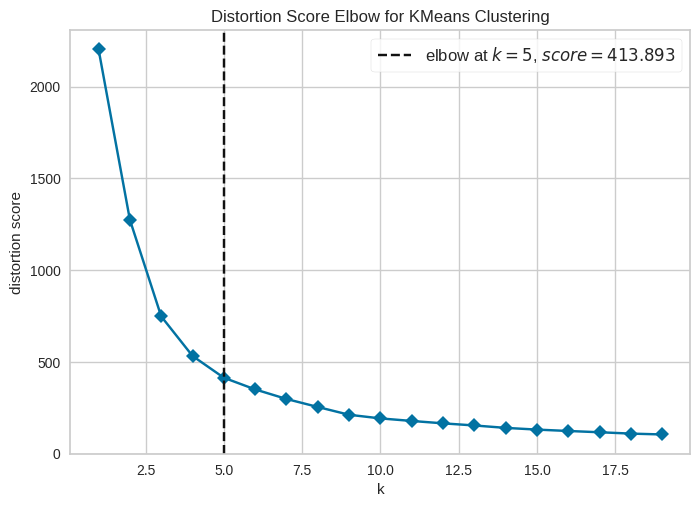

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

model = KMeans(
    init="k-means++", # new
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 20),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_science_umap)
visualizer.show()

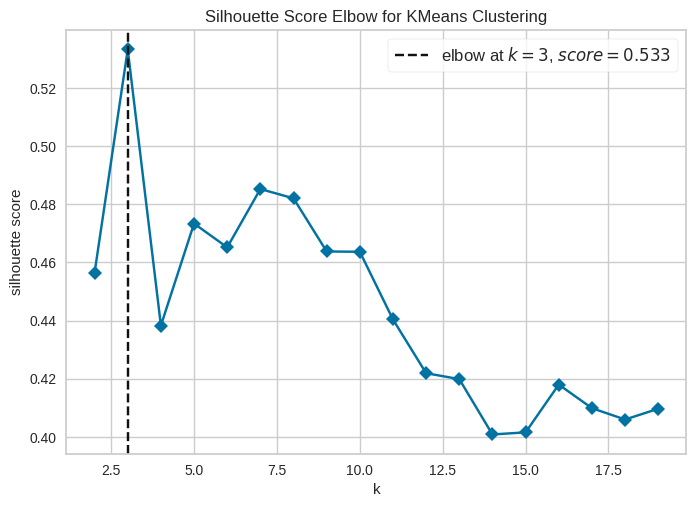

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 20),                 # test cluster range
    metric="silhouette",
    timings=False,
    random_state=42
)

visualizer.fit(embeddings_science_umap)
visualizer.show()

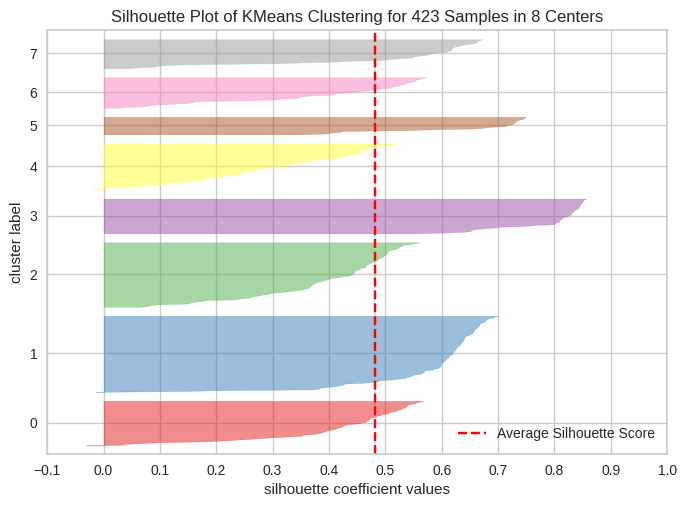

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 423 Samples in 8 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = model = KMeans(
    n_clusters=8,
    init="k-means++",
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_science_umap)        # Fit the data to the visualizer
visualizer.show()

In [ ]:
kmeans_model = KMeans(
    n_clusters=8,
    init="k-means++",
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_science['cluster_labels'] = kmeans_model.fit_predict(embeddings_science_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_science['cluster_labels'].value_counts())


cluster_labels
1    93
2    79
4    57
0    55
3    43
6    38
7    36
5    22
Name: count, dtype: int64


/tmp/ipython-input-3712128942.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_science['cluster_labels'] = kmeans_model.fit_predict(embeddings_science_umap).astype(str)


**Updates**

The number of clusters was updated from 6 to 8. This provided a higher silhouette score and lower distortion score, and identified additional grant sub-topics that were missed in M2.

###**Extracting Key Words From Each Cluster**

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

GRANT_STOPWORDS = [
    "grant", "grants",
    "funding", "funded",
    "proposal", "proposals",
    "applicant", "applicants",
    "application", "applications",
    "funding opportunity",
    "funding opportunity announcement",
    "opportunity announcement",
    "announcement",
    "program", "programs",
    "submit", "submission", "submitted",
    "eligible", "eligibility",
    "agency", "federal",
    "foa", "nofo", "cfda",
    "opportunity", "health"
]

custom_stopwords = list(ENGLISH_STOP_WORDS.union(GRANT_STOPWORDS))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_features=1000,
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.80 # remove words appearing in 80% of descriptions
)

phrase_vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_features=1000,
    ngram_range=(2,3),
    min_df=5,
    max_df=0.80
)

word_tfidf = word_vectorizer.fit_transform(details_science['description'])
word_terms = word_vectorizer.get_feature_names_out()

phrase_tfidf = phrase_vectorizer.fit_transform(details_science['description'])
phrase_terms = phrase_vectorizer.get_feature_names_out()


In [ ]:
num_clusters = details_science['cluster_labels'].nunique()

for cluster_num in range(num_clusters):

    cluster_mask = (details_science['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:5]

    words = [
        (word_terms[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:5]

    phrases = [
        (phrase_terms[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")


========== Cluster 0 ==========

Top Words:
earth                0.0769
facilities           0.0734
processes            0.0711
atmospheric          0.0702
supports             0.0563

Top Phrases:
supports research              0.1468
earth sciences                 0.0656
research education             0.0634
support research               0.0495
serving institutions           0.0478

========== Cluster 1 ==========

Top Words:
baa                  0.0818
roses                0.0677
elements             0.065
element              0.0648
text                 0.0447

Top Phrases:
research development           0.0797
united states                  0.0684
research projects              0.0578
department defense             0.0563
applied research               0.0531

========== Cluster 2 ==========

Top Words:
stem                 0.1686
education            0.0925
nsf                  0.0735
engineering          0.0615
institutions         0.0575

Top Phrases:
stem education          

In [ ]:
details_science['cluster_labels'].value_counts()

,count
cluster_labels,
1,93
2,79
4,57
0,55
3,43
6,38
7,36
5,22


**Science Sub-Topics**

*8 Clusters:*

0: Earth Sciences

1: US Defense Projects

2: STEM Education

3: Clinical Trials

4: Biological Engineering & Climate Change

5: Mathematics

6: Machine Learning & Computer Science

7: Social Behavioral Science


### **Cluster Analysis**

In [ ]:
# assign sub-topic labels to each grant
cluster_name_mapping = {
    '0': 'Earth Sciences',
    '1': 'US Defense Projects',
    '2': 'STEM Education',
    '3': 'Clinical Trials',
    '5': 'Mathematics',
    '4': 'Biological Engineering & Climate Change',
    '6': 'Machine Learning & Computer Science',
    '7': 'Social Behavioral Science',
}

if 'cluster_labels' not in details_science.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_science['cluster_labels'] = details_science['cluster_labels'].map(cluster_name_mapping)

/tmp/ipython-input-2965510161.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_science['cluster_labels'] = details_science['cluster_labels'].map(cluster_name_mapping)


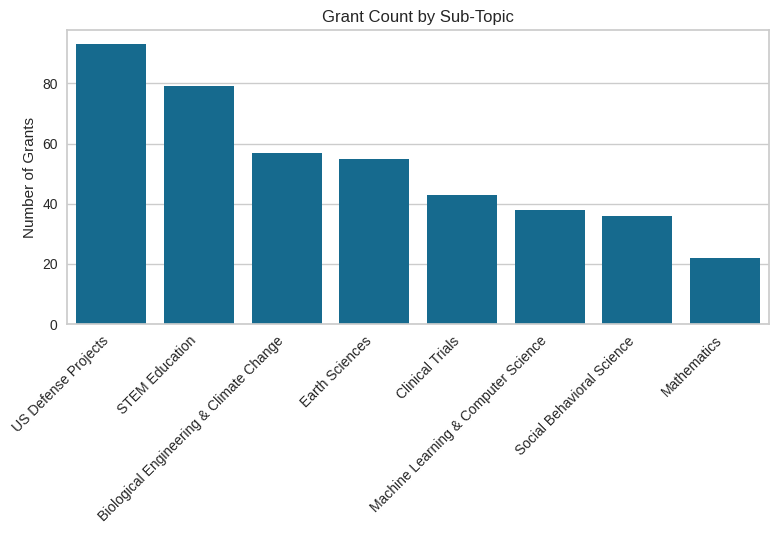

In [ ]:
#cluster count bar chart
sns.countplot(data=details_science, x='cluster_labels', order=details_science['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

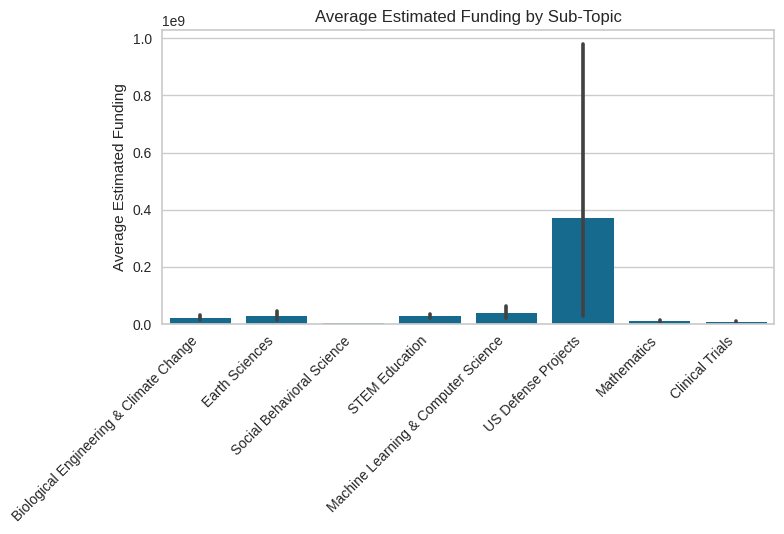

In [ ]:
#cluster by mean estimated funding
sns.barplot(data=details_science, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
total_funding_science = pd.DataFrame(details_science.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_funding_science.sort_values(by='estimated_total_program_funding', ascending=False)

,estimated_total_program_funding
cluster_labels,
US Defense Projects,6.287950e+09
STEM Education,2.020200e+09
Earth Sciences,9.878401e+08
Biological Engineering & Climate Change,9.462230e+08
Machine Learning & Computer Science,9.372000e+08
Clinical Trials,3.143320e+08
Mathematics,1.531500e+08
Social Behavioral Science,9.595000e+07


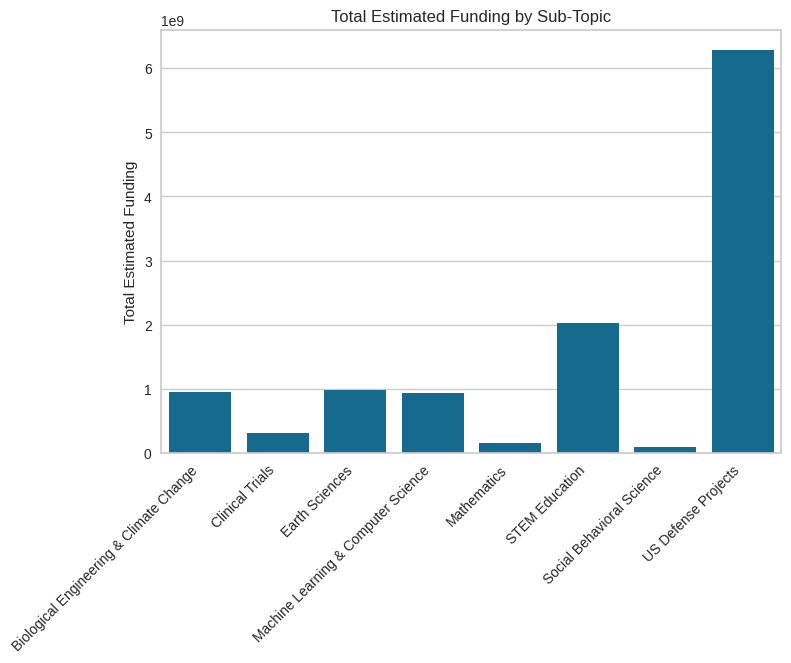

In [ ]:
sns.barplot(data=total_funding_science, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.show()

## **Education Category Clustering**

### **Creating Education DataFrame**

In [ ]:
details_education = details[details['official_category'] == 'education']
details_education.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,397.000000,18.000000,397.000000,397,397,389,390,378,2.000000e+01,1.690000e+02,1.900000e+01
mean,338260.314861,7.055556,1.279597,2022-04-08 04:46:32.947103488,2022-07-10 16:33:51.234257152,2024-08-31 15:51:21.748071936,2024-12-25 05:02:46.153846272,2025-03-21 23:29:31.428571392,2.533998e+08,2.210370e+06,1.419737e+06
min,49325.000000,1.000000,1.000000,2009-09-02 00:00:00,2011-04-27 00:00:00,2009-07-29 00:00:00,2009-07-29 00:00:00,2023-10-29 00:00:00,2.000000e+04,0.000000e+00,0.000000e+00
25%,335530.000000,1.000000,1.000000,2021-09-02 00:00:00,2021-11-22 00:00:00,2023-12-11 00:00:00,2024-01-08 00:00:00,2024-03-06 12:00:00,1.000000e+07,2.750000e+05,0.000000e+00
50%,343044.000000,1.000000,1.000000,2022-08-09 00:00:00,2022-11-22 00:00:00,2024-09-07 00:00:00,2024-09-07 00:00:00,2024-10-13 00:00:00,2.312500e+07,3.500000e+05,2.500000e+04
75%,348051.000000,5.750000,1.000000,2023-05-10 00:00:00,2023-05-26 00:00:00,2025-06-13 00:00:00,2025-06-17 00:00:00,2025-08-11 06:00:00,5.500000e+07,5.000000e+05,1.000000e+06
max,350389.000000,52.000000,18.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-02-08 00:00:00,2121-10-12 00:00:00,2121-11-11 00:00:00,4.350000e+09,6.000000e+07,1.000000e+07
std,25880.534130,12.581369,1.152473,NaN,NaN,NaN,NaN,NaN,9.650793e+08,7.746578e+06,2.944446e+06


### **Text Embedding**

In [ ]:
embeddings_education = embedding_model.encode(
    details_education["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_education = np.asarray(embeddings_education, dtype=np.float32)

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:
umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_education_umap = umap_model.fit_transform(embeddings_education)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### **K-Means Clustering**

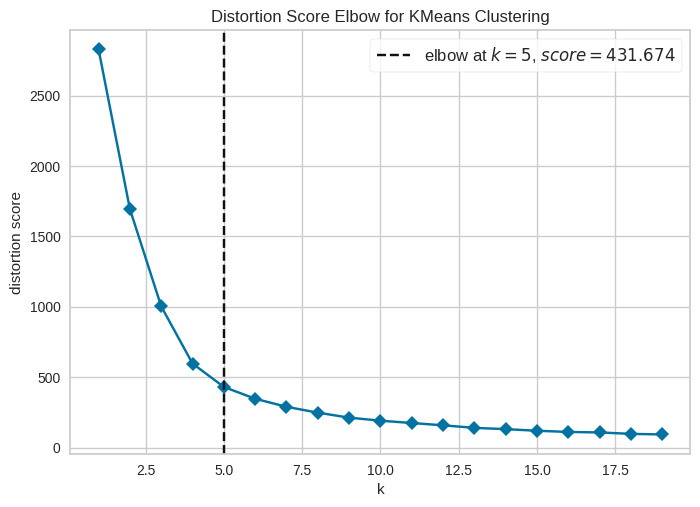

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(
    init="k-means++", # enhanced initialization
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 20),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_education_umap)
visualizer.show()

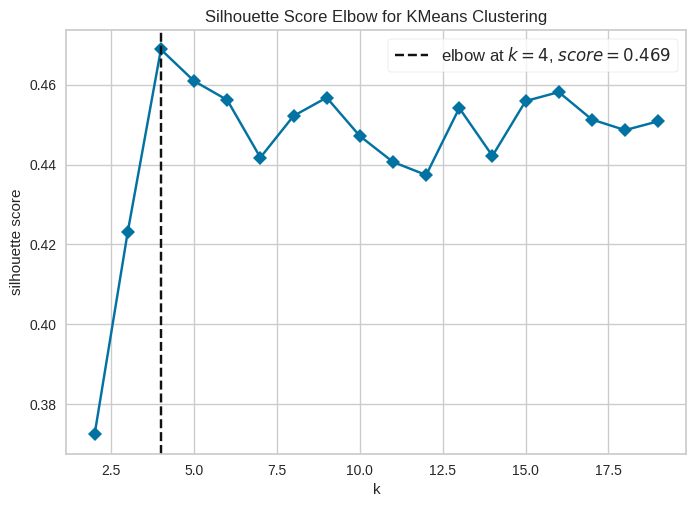

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 20),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_education_umap)
visualizer.show()

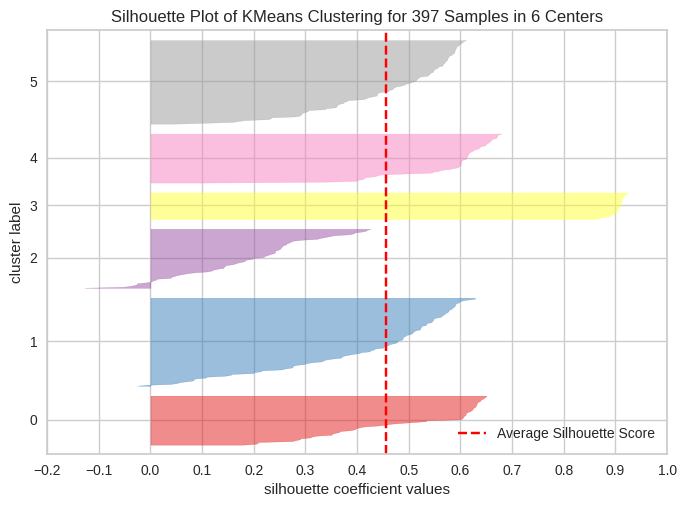

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 397 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
kmeans_model = model = KMeans(
    n_clusters=6,
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_education_umap)        # Fit the data to the visualizer
visualizer.show()

In [ ]:
kmeans_model = model = KMeans(
    n_clusters=6,
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)

# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_education['cluster_labels'] = kmeans_model.fit_predict(embeddings_education_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_education['cluster_labels'].value_counts())


cluster_labels
1    98
5    93
2    66
4    55
0    55
3    30
Name: count, dtype: int64


/tmp/ipython-input-3843799194.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_education['cluster_labels'] = kmeans_model.fit_predict(embeddings_education_umap).astype(str)


**Updates**

The number of clusters was updated from 4 to 6. While this slightly reduced the average silhoutte score, it was able to better identify and separate unclear sub-topics from M2.

### **Extracting Key Words From Each Cluster**

In [ ]:
word_tfidf_education = word_vectorizer.fit_transform(details_education['description'])
word_terms_education = word_vectorizer.get_feature_names_out()

phrase_tfidf_education = phrase_vectorizer.fit_transform(details_education['description'])
phrase_terms_education = phrase_vectorizer.get_feature_names_out()


In [ ]:
num_clusters_education = details_education['cluster_labels'].nunique()

for cluster_num in range(num_clusters_education):

    cluster_mask = (details_education['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf_education[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:5]

    words = [
        (word_terms_education[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf_education[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:5]

    phrases = [
        (phrase_terms_education[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")


========== Cluster 0 ==========

Top Words:
brain                0.1057
pain                 0.0808
tools                0.0547
projects             0.0525
technologies         0.048

Top Phrases:
brain initiative               0.0973
neuroscience research          0.0451
pain conditions                0.0421
comply dmsp                    0.0381
central nervous                0.0355

========== Cluster 1 ==========

Top Words:
use                  0.0681
hiv                  0.0663
substance            0.058
interventions        0.0511
support              0.0459

Top Phrases:
substance use                  0.0971
purpose support                0.0623
drug abuse                     0.0598
use disorders                  0.0514
support research               0.0507

========== Cluster 2 ==========

Top Words:
nih                  0.083
clinical             0.0747
trial                0.0547
project              0.0529
studies              0.0508

Top Phrases:
research projects         

**Education Sub-Topics**

0: Brain Initiatives & Neuroscience

1: Substance Use

2: Clinical Trials

3: Higher Education

4: Independent Research & Career Development

5: Cancer

###**Cluster Analysis**

In [ ]:
# assign sub-topic labels to each grant
cluster_name_mapping = {
    '0': 'Brain Initiatives & Neuroscience',
    '1': 'Substance Use',
    '2': 'Clinical Trials',
    '3': 'Higher Education',
    '4': 'Independent Research & Career Development',
    '5': 'Cancer'
}

if 'cluster_labels' not in details_education.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_education['cluster_labels'] = details_education['cluster_labels'].map(cluster_name_mapping)

/tmp/ipython-input-2783528804.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_education['cluster_labels'] = details_education['cluster_labels'].map(cluster_name_mapping)


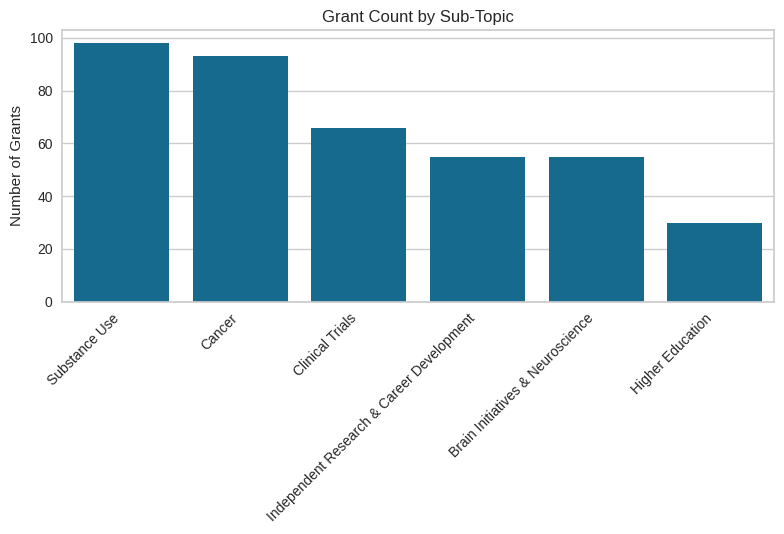

In [ ]:
#cluster count bar chart
sns.countplot(data=details_education, x='cluster_labels', order=details_education['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

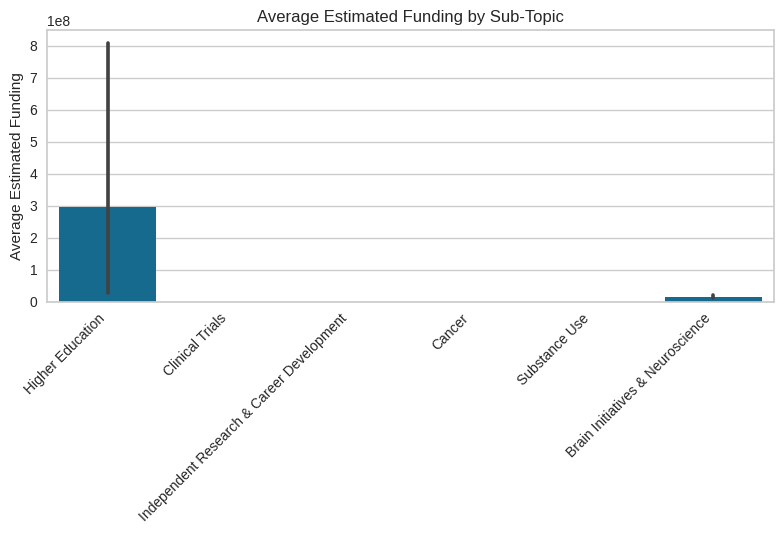

In [ ]:
#cluster by mean estimated funding
sns.barplot(data=details_education, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
total_funding_education = pd.DataFrame(details_education.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_funding_education.sort_values(by='estimated_total_program_funding', ascending=False)

,estimated_total_program_funding
cluster_labels,
Higher Education,5.025996e+09
Brain Initiatives & Neuroscience,4.200000e+07
Cancer,0.000000e+00
Clinical Trials,0.000000e+00
Independent Research & Career Development,0.000000e+00
Substance Use,0.000000e+00


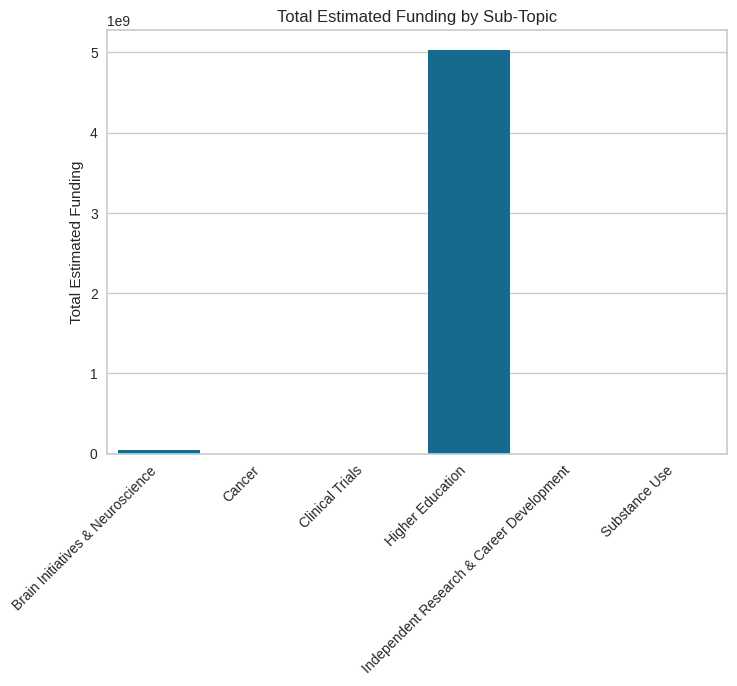

In [ ]:
sns.barplot(data=total_funding_education, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.show()

## **Other Category Clustering**

### **Creating Other DataFrame**

In [ ]:
details_other = details[details['official_category'] == 'other']
details_other.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,106.000000,62.000000,106.000000,106,106,71,71,46,5.300000e+01,9.700000e+01,9.600000e+01
mean,317029.679245,60.290323,3.283019,2021-01-05 00:40:45.283018752,2021-06-07 07:28:18.113207552,2027-08-16 12:30:25.352112640,2028-02-24 11:49:51.549295872,2024-03-13 15:39:07.826086912,4.404545e+07,1.211688e+07,1.046537e+06
min,40112.000000,0.000000,1.000000,2007-11-28 00:00:00,2007-11-28 00:00:00,2017-12-18 00:00:00,2017-08-13 00:00:00,2023-10-29 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,325882.500000,1.000000,1.000000,2020-03-30 18:00:00,2021-09-09 06:00:00,2023-06-15 12:00:00,2023-09-30 00:00:00,2023-11-18 06:00:00,3.250000e+05,3.800000e+04,0.000000e+00
50%,344043.500000,5.000000,2.000000,2022-10-13 00:00:00,2023-02-11 00:00:00,2023-10-06 00:00:00,2023-11-16 00:00:00,2024-01-16 12:00:00,4.740000e+06,1.000000e+06,5.000000e+03
75%,348756.000000,10.000000,4.000000,2023-07-07 00:00:00,2023-07-26 18:00:00,2023-12-26 12:00:00,2024-03-21 12:00:00,2024-05-08 00:00:00,2.000000e+07,5.000000e+06,2.500000e+05
max,350362.000000,3000.000000,19.000000,2023-09-27 00:00:00,2023-09-28 00:00:00,2099-01-01 00:00:00,2099-01-01 00:00:00,2025-05-26 00:00:00,5.000000e+08,3.749813e+08,3.080000e+07
std,67747.210249,380.149642,3.362977,NaN,NaN,NaN,NaN,NaN,1.108145e+08,4.227019e+07,3.761251e+06


### **Text Embedding**

In [ ]:
embeddings_other = embedding_model.encode(
    details_other["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_other = np.asarray(embeddings_other, dtype=np.float32)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_other_umap = umap_model.fit_transform(embeddings_other)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### **K-Means Clustering**

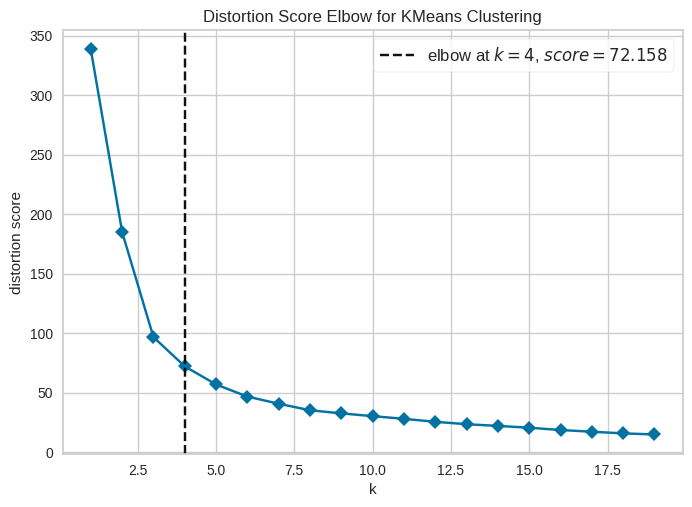

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(
    init="k-means++", # enhanced initialization
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 20),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_other_umap)
visualizer.show()

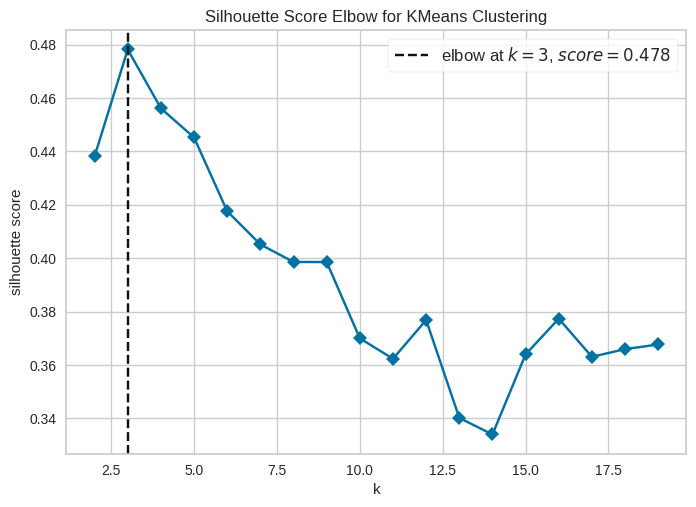

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 20),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_other_umap)
visualizer.show()

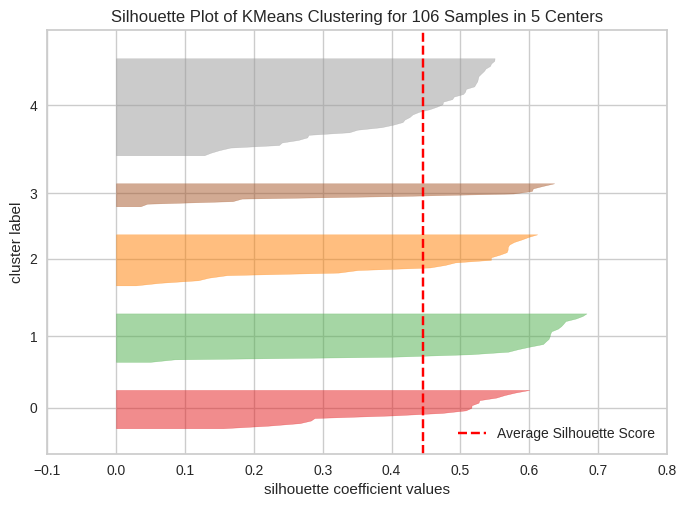

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 106 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
kmeans_model = model = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_other_umap)        # Fit the data to the visualizer
visualizer.show()

In [ ]:
# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_other['cluster_labels'] = kmeans_model.fit_predict(embeddings_other_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_other['cluster_labels'].value_counts())


cluster_labels
4    39
2    21
1    20
0    16
3    10
Name: count, dtype: int64


/tmp/ipython-input-982936501.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_other['cluster_labels'] = kmeans_model.fit_predict(embeddings_other_umap).astype(str)


**No 'Other' Category Cluster Updates from M2**

### **Extracting Key Words From Each Cluster**

In [ ]:
word_tfidf_other = word_vectorizer.fit_transform(details_other['description'])
word_terms_other = word_vectorizer.get_feature_names_out()

phrase_tfidf_other = phrase_vectorizer.fit_transform(details_other['description'])
phrase_terms_other = phrase_vectorizer.get_feature_names_out()


In [ ]:
num_clusters_other = details_other['cluster_labels'].nunique()

for cluster_num in range(num_clusters_other):

    cluster_mask = (details_other['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf_other[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:5]

    words = [
        (word_terms_other[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf_other[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:5]

    phrases = [
        (phrase_terms_other[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")


========== Cluster 0 ==========

Top Words:
labor                0.2006
agreement            0.1019
cooperative          0.0762
notice               0.0716
department           0.0689

Top Phrases:
cooperative agreement          0.1672
notice intent                  0.1239
international labor            0.1221
fiscal year                    0.0925
labor affairs                  0.0887

========== Cluster 1 ==========

Top Words:
embassy              0.1058
cultural             0.0961
american             0.0928
public               0.0857
include              0.0833

Top Phrases:
united states                  0.1793
public diplomacy               0.1304
human rights                   0.1157
civil society                  0.0966
department state               0.0831

========== Cluster 2 ==========

Top Words:
economic             0.1104
eda                  0.1066
planning             0.0971
state                0.0848
edge                 0.0743

Top Phrases:
economic development   

**Other Sub-Topics**

Cluster 0: Labor Affairs & Cooperations

Cluster 1: Public Diplomacy & Human Rights

Cluster 2: Economic Development

Cluster 3: Historical and Cultural Preservation

Cluster 4: International Development

**Updates**

While the clusters remain the same, Cluster 4 was renamed from 'Private Sector' to 'International Development' based on additional grant research and inspection.

#### **Cluster 4 Grant Description Inspection**

In [ ]:
descriptions_4 = pd.DataFrame(details_other[details_other['cluster_labels']=='4']['description'])

In [ ]:
# description in descriptions_4 contains 'private sector'
descriptions_4[descriptions_4['description'].str.contains('private sector')]

,description
32,clinical trials of vaginal microbicide have be...
74,this annual program statement aps is designed ...
77,the united states agency for international dev...
116,this usaidsahel regional office sro rfi is iss...
296,usaidkea welcomes concept papers from kenyaled...
319,through this addendum to the 20202023 global d...
483,through this addendum to the global developmen...
698,usaidguinea sierra leone seeks to engage the ...
981,usaidtanzania seeks to build partnerships with...
1268,pursuant to the foreign assistance act of 1961...


### **Cluster Analysis**

In [ ]:
# assign sub-topic labels to each grant
cluster_name_mapping = {
    '0': 'Labor Affairs & Cooperations',
    '1': 'Public Diplomacy & Human Rights',
    '2': 'Economic Development',
    '3': 'Historical and Cultural Preservation',
    '4': 'International Development'
}

if 'cluster_labels' not in details_other.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_other['cluster_labels'] = details_other['cluster_labels'].map(cluster_name_mapping)

/tmp/ipython-input-1811996594.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_other['cluster_labels'] = details_other['cluster_labels'].map(cluster_name_mapping)


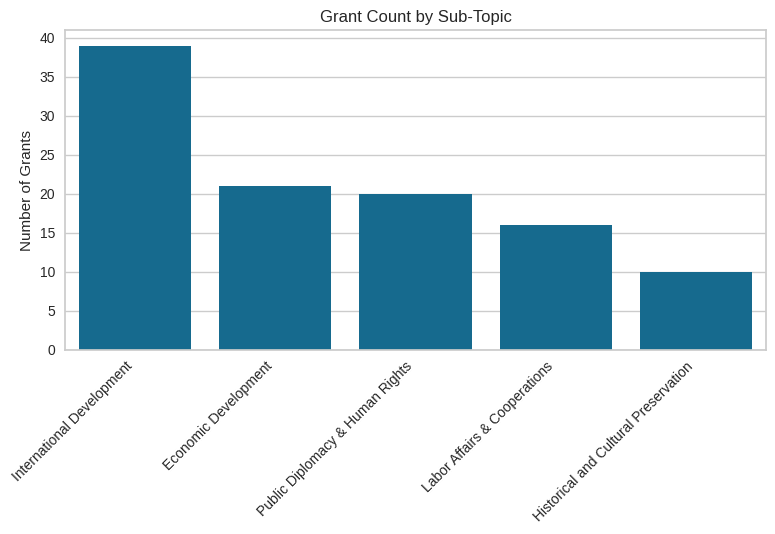

In [ ]:
#cluster count bar chart
sns.countplot(data=details_other, x='cluster_labels', order=details_other['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

International Development and Economic Development have the largest proportion of grants in the other category, while historical and cultural preservation has only 10 grants. This could be attributed to similar grants being categorized in other broad grant categories.

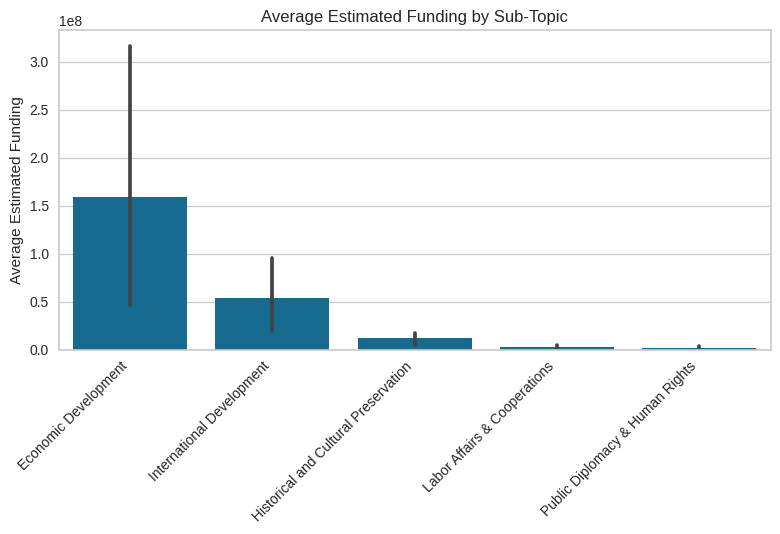

In [ ]:
#cluster by mean estimated funding
sns.barplot(data=details_other, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Economic development has the highest average funding per grant, followed by the private sector. Given the share of these grants is also the greatest in this category, we can conclude that these sub-domains dominate the 'other' category.

In [ ]:
total_funding_other = pd.DataFrame(details_other.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_funding_other.sort_values(by='estimated_total_program_funding', ascending=False)

,estimated_total_program_funding
cluster_labels,
Economic Development,1.432731e+09
International Development,7.484000e+08
Historical and Cultural Preservation,1.052915e+08
Labor Affairs & Cooperations,2.932075e+07
Public Diplomacy & Human Rights,1.866500e+07


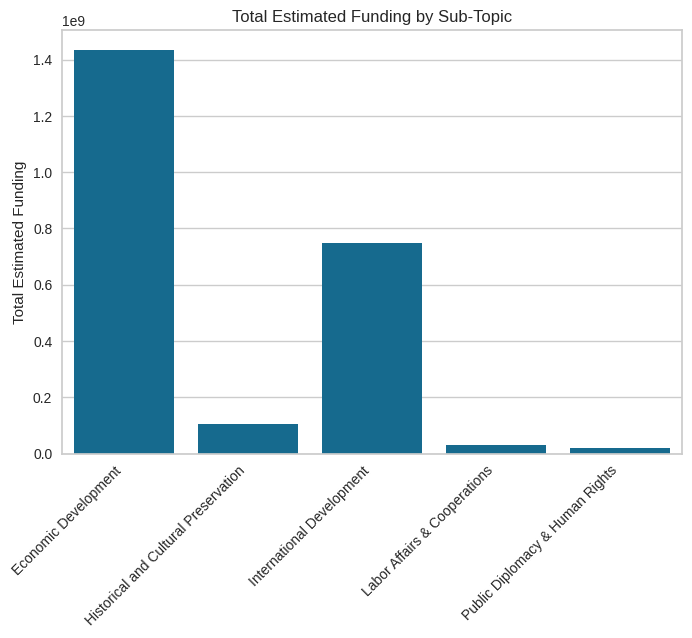

In [ ]:
sns.barplot(data=total_funding_other, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.show()

**Analysis**

This graph shows the same patterns seen in the previous two graphs, with economic development and the private sector dominating total grant funding in the 'other' category.

## **Environment Category Clustering**

### **Create Environment DataFrame**

In [ ]:
details_environment = details[details['official_category'] == 'environment']
details_environment.describe()

,opportunity_id,expected_number_of_awards,version,posted_date,last_updated_date,original_closing_date_for_applications,current_closing_date_for_applications,archive_date,estimated_total_program_funding,award_ceiling,award_floor
count,92.000000,53.000000,92.000000,92,92,91,91,77,5.700000e+01,7.700000e+01,5.400000e+01
mean,341867.771739,19.113208,2.217391,2022-10-29 09:54:46.956521728,2022-11-26 02:52:10.434782720,2023-09-25 07:54:43.516483584,2023-10-21 15:49:27.032966912,2024-04-22 05:36:37.402597376,5.834098e+08,2.792460e+08,8.771604e+05
min,103313.000000,1.000000,1.000000,2011-07-06 00:00:00,2011-07-07 00:00:00,2011-07-26 00:00:00,2011-07-26 00:00:00,2023-10-26 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,344955.250000,1.000000,1.000000,2022-12-13 12:00:00,2022-12-13 12:00:00,2023-10-12 00:00:00,2023-10-21 00:00:00,2023-11-30 00:00:00,1.500000e+06,3.000000e+05,0.000000e+00
50%,349686.000000,5.000000,1.000000,2023-08-04 12:00:00,2023-08-18 00:00:00,2023-11-13 00:00:00,2023-11-13 00:00:00,2023-12-31 00:00:00,5.280000e+06,1.500000e+06,2.500000e+04
75%,350170.000000,25.000000,3.000000,2023-09-11 18:00:00,2023-09-14 00:00:00,2024-01-04 00:00:00,2024-01-28 00:00:00,2024-05-25 00:00:00,5.000000e+07,1.130000e+07,1.196192e+05
max,350380.000000,115.000000,11.000000,2023-09-28 00:00:00,2023-09-28 00:00:00,2028-09-30 00:00:00,2028-09-30 00:00:00,2028-11-01 00:00:00,1.397000e+10,1.397000e+10,2.500000e+07
std,28187.412077,27.451118,1.926256,NaN,NaN,NaN,NaN,NaN,2.234563e+09,1.722884e+09,3.855582e+06


### **Text Embedding**

In [ ]:
embeddings_environment = embedding_model.encode(
    details_environment["description"].tolist(),   # convert to list for speed
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings_environment = np.asarray(embeddings_environment, dtype=np.float32)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
umap_model = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

embeddings_environment_umap = umap_model.fit_transform(embeddings_environment)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


###**K-Means Clustering**

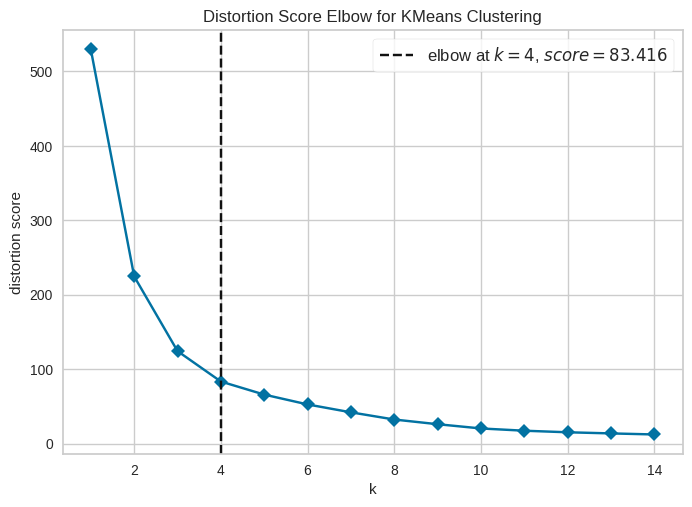

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(
    init="k-means++", # enhanced initialization
    n_init=10,      # increase iterations
    max_iter=500,   # ensures convergence
    random_state=42
)

visualizer = KElbowVisualizer(
    model,
    k=(1, 15),                 # test cluster range
    metric="distortion",
    timings=False
)

visualizer.fit(embeddings_environment_umap)
visualizer.show()

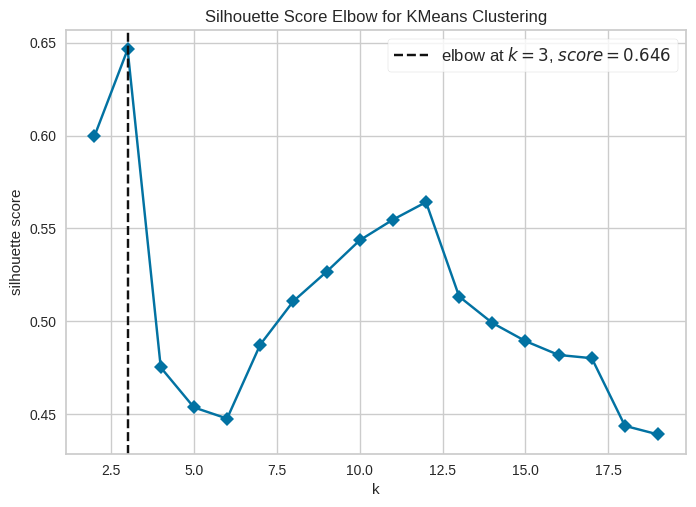

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
visualizer = KElbowVisualizer(
    model,
    k=(2, 20),                 # test cluster range
    metric="silhouette",
    timings=False
)

visualizer.fit(embeddings_environment_umap)
visualizer.show()

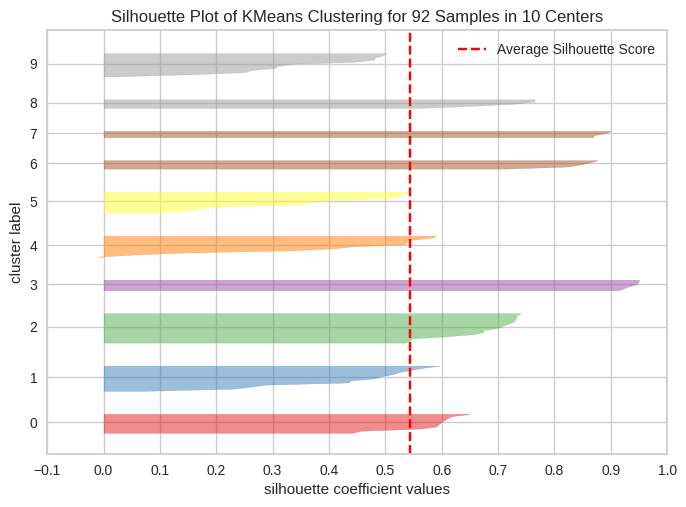

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 92 Samples in 10 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
kmeans_model = model = KMeans(
    n_clusters=10,
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(embeddings_environment_umap)        # Fit the data to the visualizer
visualizer.show()

In [ ]:
# Fit the model and predict cluster labels, excluding the existing 'cluster_labels' column
details_environment['cluster_labels'] = kmeans_model.fit_predict(embeddings_environment_umap).astype(str)

# Display the value counts of the new cluster labels
print(details_environment['cluster_labels'].value_counts())


cluster_labels
2    15
1    13
9    12
4    11
5    11
0    10
3     6
6     5
8     5
7     4
Name: count, dtype: int64


/tmp/ipython-input-588977908.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_environment['cluster_labels'] = kmeans_model.fit_predict(embeddings_environment_umap).astype(str)


**Updates**

The number of clusters was updated from 4 to 10. While the silhouette score decreased, the higher number of clusters better identified to sub topics within the Environment Category. 12 clusters was not chosen, despite its higher silhouette score than 10 clusters, because the key words identified in each cluster had a few clusters with similar sub-topics, indicating that their differences were likely stylistic, rather than thematic. 10 clusters was the most informative for this domain question.

###**Extracting Key Words From Each Cluster**

In [ ]:
word_tfidf_environment = word_vectorizer.fit_transform(details_environment['description'])
word_terms_environment = word_vectorizer.get_feature_names_out()

phrase_tfidf_environment = phrase_vectorizer.fit_transform(details_environment['description'])
phrase_terms_environment = phrase_vectorizer.get_feature_names_out()


In [ ]:
num_clusters_environment = details_environment['cluster_labels'].nunique()

for cluster_num in range(num_clusters_environment):

    cluster_mask = (details_environment['cluster_labels'] == str(cluster_num)).to_numpy()

    # WORDS
    cluster_word_matrix = word_tfidf_environment[cluster_mask]
    word_means = np.asarray(cluster_word_matrix.mean(axis=0)).flatten()

    top_word_indices = word_means.argsort()[::-1][:5]

    words = [
        (word_terms_environment[i], round(word_means[i], 4))
        for i in top_word_indices
    ]


    # PHRASES
    cluster_phrase_matrix = phrase_tfidf_environment[cluster_mask]
    phrase_means = np.asarray(cluster_phrase_matrix.mean(axis=0)).flatten()

    top_phrase_indices = phrase_means.argsort()[::-1][:5]

    phrases = [
        (phrase_terms_environment[i], round(phrase_means[i], 4))
        for i in top_phrase_indices
    ]

    print(f"\n========== Cluster {cluster_num} ==========")

    print("\nTop Words:")
    for word, score in words:
        print(f"{word:<20} {score}")

    print("\nTop Phrases:")
    for phrase, score in phrases:
        print(f"{phrase:<30} {score}")


========== Cluster 0 ==========

Top Words:
usaid                0.3308
activity             0.2734
vietnam              0.1433
development          0.0958
government           0.0891

Top Phrases:
united states                  0.3935
international development      0.3794
provides information           0.0604
utilization investment         0.0
tribal nations communities     0.0

========== Cluster 1 ==========

Top Words:
epa                  0.2002
competition          0.1495
communities          0.1159
environmental        0.0972
organizations        0.0966

Top Phrases:
technical assistance           0.165
disadvantaged communities      0.158
environmental justice          0.1485
environmental protection       0.1316
including limited              0.1089

========== Cluster 2 ==========

Top Words:
research             0.3118
disorders            0.1264
data                 0.1181
scientists           0.1152
environmental        0.1027

Top Phrases:
substance use                  

**Environment Sub-Topics**

0: International Development

1: Environmental Justice

2: Substance Use Research

3: Brownfields Revitalization

4: Underserved Communities

5: Forest & Land Restoration

6: Environmental Education

7: Climate Change

8: Water

9: Endangered Species

#### **Cluster 4 Inspection**

In [ ]:
cluster_4 = pd.DataFrame(details_environment[details_environment['cluster_labels'] == '4']['description'])
cluster_4

,description
20,changing climate confronts society with signif...
219,this notice is not a mechanism to fund existin...
967,the national park service nps are seeking appl...
1601,the objective of the program is to provide a b...
1746,the purpose of this document is to advise the ...
1773,noaas weather program office wpo wponoaagovnof...
1805,the principal objective of this funding opport...
1825,epa is soliciting applications from eligible e...
1920,the purpose of this document is to advise the ...
1966,the objective of section 309 is to encourage s...


###**Cluster Analysis**

In [ ]:
# assign sub-topic labels to each environment grant
cluster_name_mapping = {
    '0': 'International Development',
    '1': 'Environmental Justice',
    '2': 'Substance Use Research',
    '3': 'Brownfields',
    '4': 'Underserved Communities',
    '5': 'Forest & Land Restoration',
    '6': 'Environmental Education',
    '7': 'Climate Change',
    '8': 'Water',
    '9': 'Endangered Species'
}

if 'cluster_labels' not in details_environment.columns:
    print("Error: 'cluster_labels' column not found. Please ensure the K-Means clustering cell was executed successfully.")
else:
    details_environment['cluster_labels'] = details_environment['cluster_labels'].map(cluster_name_mapping)

/tmp/ipython-input-3267961916.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  details_environment['cluster_labels'] = details_environment['cluster_labels'].map(cluster_name_mapping)


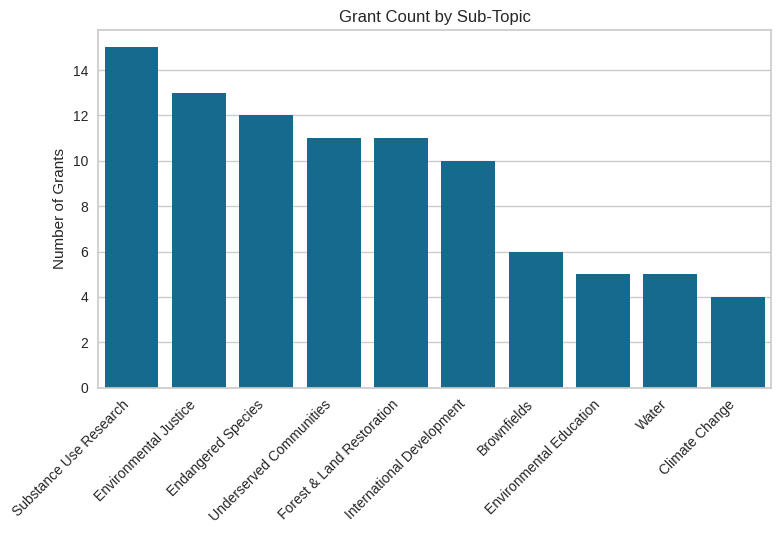

In [ ]:
#cluster count bar chart
sns.countplot(data=details_environment, x='cluster_labels', order=details_environment['cluster_labels'].value_counts().index)
plt.title("Grant Count by Sub-Topic")
plt.xlabel("")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

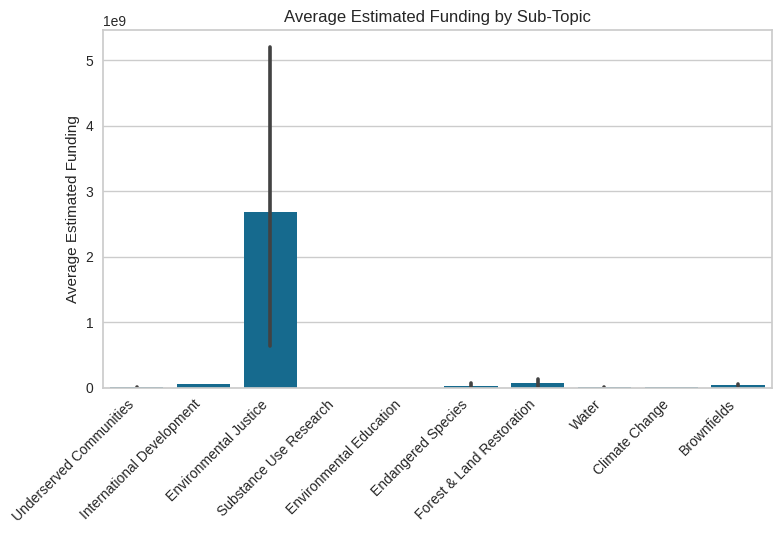

In [ ]:
#cluster by mean estimated funding
sns.barplot(data=details_environment, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Average Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Average Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
total_funding_environment = pd.DataFrame(details_environment.groupby('cluster_labels')['estimated_total_program_funding'].sum())
total_funding_environment

,estimated_total_program_funding
cluster_labels,
Brownfields,2.390000e+08
Climate Change,9.300000e+06
Endangered Species,2.962800e+08
Environmental Education,1.440000e+06
Environmental Justice,3.216000e+10
Forest & Land Restoration,4.428120e+08
International Development,5.500000e+07
Substance Use Research,0.000000e+00
Underserved Communities,4.160000e+07


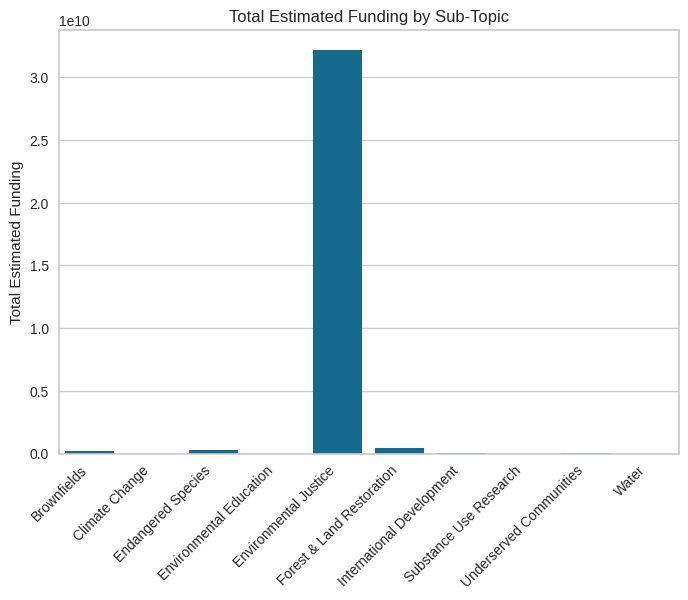

In [ ]:
sns.barplot(data=total_funding_environment, x='cluster_labels', y='estimated_total_program_funding')
plt.title("Total Estimated Funding by Sub-Topic")
plt.xlabel("")
plt.ylabel("Total Estimated Funding")
plt.xticks(rotation=45, ha='right')
plt.show()

# **Grant Sub-Topic Additional Analysis**

### Merging Category DataFrames

In [111]:
top_categories = ['science', 'environment', 'health', 'other', 'education']

# Initialize 'sub_topic' column
details['sub_topic'] = None

# Assign topic clusters to grants in details df
def get_sub_topic(row):
    if row['official_category'] == 'health' and row['opportunity_id'] in details_health['opportunity_id'].values:
        return details_health.loc[details_health['opportunity_id'] == row['opportunity_id'], 'cluster_labels'].iloc[0]
    elif row['official_category'] == 'science' and row['opportunity_id'] in details_science['opportunity_id'].values:
        return details_science.loc[details_science['opportunity_id'] == row['opportunity_id'], 'cluster_labels'].iloc[0]
    elif row['official_category'] == 'environment' and row['opportunity_id'] in details_environment['opportunity_id'].values:
        return details_environment.loc[details_environment['opportunity_id'] == row['opportunity_id'], 'cluster_labels'].iloc[0]
    elif row['official_category'] == 'education' and row['opportunity_id'] in details_education['opportunity_id'].values:
        return details_education.loc[details_education['opportunity_id'] == row['opportunity_id'], 'cluster_labels'].iloc[0]
    elif row['official_category'] == 'other' and row['opportunity_id'] in details_other['opportunity_id'].values:
        return details_other.loc[details_other['opportunity_id'] == row['opportunity_id'], 'cluster_labels'].iloc[0]
    else:
        return row['official_category']

details['sub_topic'] = details.apply(get_sub_topic, axis=1)


### **Sub Topic Summary**

In [154]:
topic_summary = details.groupby('sub_topic').agg(n_opps=('opportunity_id', 'count'),
                                                 avg_funding=('estimated_total_program_funding', 'mean'),
                                                 med_funding=('estimated_total_program_funding', 'median'),
                                                 avg_awards=('expected_number_of_awards', 'mean'),
                                                 med_awards=('expected_number_of_awards', 'median'),
                                                 funding_missing_rate=('estimated_total_program_funding', lambda s: s.isna().mean()))

topic_summary.sort_values('n_opps', ascending=False)

,n_opps,avg_funding,med_funding,avg_awards,med_awards,funding_missing_rate
sub_topic,,,,,,
Clinical Trials,125,7.200727e+06,3720000.0,4.651163,3.0,0.648000
Independent Research & Career Development,105,2.000000e+07,20000000.0,20.000000,20.0,0.980952
Substance Use,98,NaN,NaN,NaN,NaN,1.000000
Cancer,93,NaN,NaN,NaN,NaN,1.000000
US Defense Projects,93,3.698794e+08,16000000.0,40305.920000,40.0,0.817204
STEM Education,79,2.730000e+07,15000000.0,82.358491,30.0,0.063291
Alzheimers & Dementia,72,7.500000e+06,7500000.0,8.000000,8.0,0.986111
Biological Engineering & Climate Change,57,2.150507e+07,10000000.0,30.160000,14.0,0.228070
Brain Initiatives & Neuroscience,55,1.400000e+07,10000000.0,5.000000,5.0,0.945455


### **Sub Topics with the Most  Number of Grants**

In [156]:
# Sub Topics with the most grants
top_5_opps = topic_summary.sort_values('n_opps', ascending=False).head(5)
top_5_opps

,n_opps,avg_funding,med_funding,avg_awards,med_awards,funding_missing_rate
sub_topic,,,,,,
Clinical Trials,125,7.200727e+06,3720000.0,4.651163,3.0,0.648000
Independent Research & Career Development,105,2.000000e+07,20000000.0,20.000000,20.0,0.980952
Substance Use,98,NaN,NaN,NaN,NaN,1.000000
Cancer,93,NaN,NaN,NaN,NaN,1.000000
US Defense Projects,93,3.698794e+08,16000000.0,40305.920000,40.0,0.817204


**Analysis**

Despite Substance Use and Cancer grants missing some grant funding information, we can see they are prominent topics. Clinical Trials and Independent Research have the most amount of grants, and these sub-categories spread across multiple broad categories. US Defense has the 5th most number of grants, but the highest average funding and the highest average and median number of awards.

### **Sub Topics with the Highest Average Funding**

In [157]:
top_5_med_funding = topic_summary.sort_values('med_funding', ascending=False).head(5)
top_5_med_funding

,n_opps,avg_funding,med_funding,avg_awards,med_awards,funding_missing_rate
sub_topic,,,,,,
Environmental Justice,13,2.680000e+09,207500000.0,35.923077,8.0,0.076923
transportation,13,1.302395e+09,109975497.0,25.636364,10.0,0.153846
employment,11,4.261289e+08,95016000.0,61.000000,33.5,0.272727
community_development,13,5.717500e+07,74000000.0,4.500000,1.0,0.538462
International Aid,47,9.915307e+07,60000000.0,27.750000,13.0,0.425532


In [158]:
top_5_avg_funding = topic_summary.sort_values('avg_funding', ascending=False).head(5)
top_5_avg_funding

,n_opps,avg_funding,med_funding,avg_awards,med_awards,funding_missing_rate
sub_topic,,,,,,
Environmental Justice,13,2.680000e+09,207500000.0,35.923077,8.0,0.076923
transportation,13,1.302395e+09,109975497.0,25.636364,10.0,0.153846
housing,12,4.614050e+08,57500000.0,728.750000,16.5,0.000000
employment,11,4.261289e+08,95016000.0,61.000000,33.5,0.272727
US Defense Projects,93,3.698794e+08,16000000.0,40305.920000,40.0,0.817204


**Analysis**

Across both average and median funding, Environmental Justive, transportation, and employement are in the top 5 largest grant funding topics. Community Development, housing, International Aid, and US defense projects also appear on at least one of these lists, but US Defense Projects have a significantly higher number of grants than any other topic with the highest funding.



### **Sub Topics with the Lowest Average Funding**

In [159]:
bottom_5_med_funding = topic_summary.sort_values('med_funding', ascending=True).head(5)
bottom_5_med_funding

,n_opps,avg_funding,med_funding,avg_awards,med_awards,funding_missing_rate
sub_topic,,,,,,
opportunity_zone,6,1.000000e+07,0.0,5.000000,0.0,0.0
Public Diplomacy & Human Rights,20,1.555417e+06,200000.0,6.153846,6.0,0.4
Environmental Education,5,3.600000e+05,360000.0,5.000000,5.0,0.2
Water,5,2.231500e+06,1323000.0,1.000000,1.0,0.2
humanities,18,4.429722e+06,1350000.0,18.722222,13.5,0.0


In [160]:
bottom_5_avg_funding = topic_summary.sort_values('avg_funding', ascending=True).head(5)
bottom_5_avg_funding

,n_opps,avg_funding,med_funding,avg_awards,med_awards,funding_missing_rate
sub_topic,,,,,,
Environmental Education,5,3.600000e+05,360000.0,5.000000,5.0,0.200000
Public Diplomacy & Human Rights,20,1.555417e+06,200000.0,6.153846,6.0,0.400000
food,47,1.650000e+06,1550000.0,10.000000,9.0,0.914894
Water,5,2.231500e+06,1323000.0,1.000000,1.0,0.200000
Climate Change,4,2.325000e+06,2495000.0,17.750000,20.0,0.000000


### **Distribution of Sub Topics**

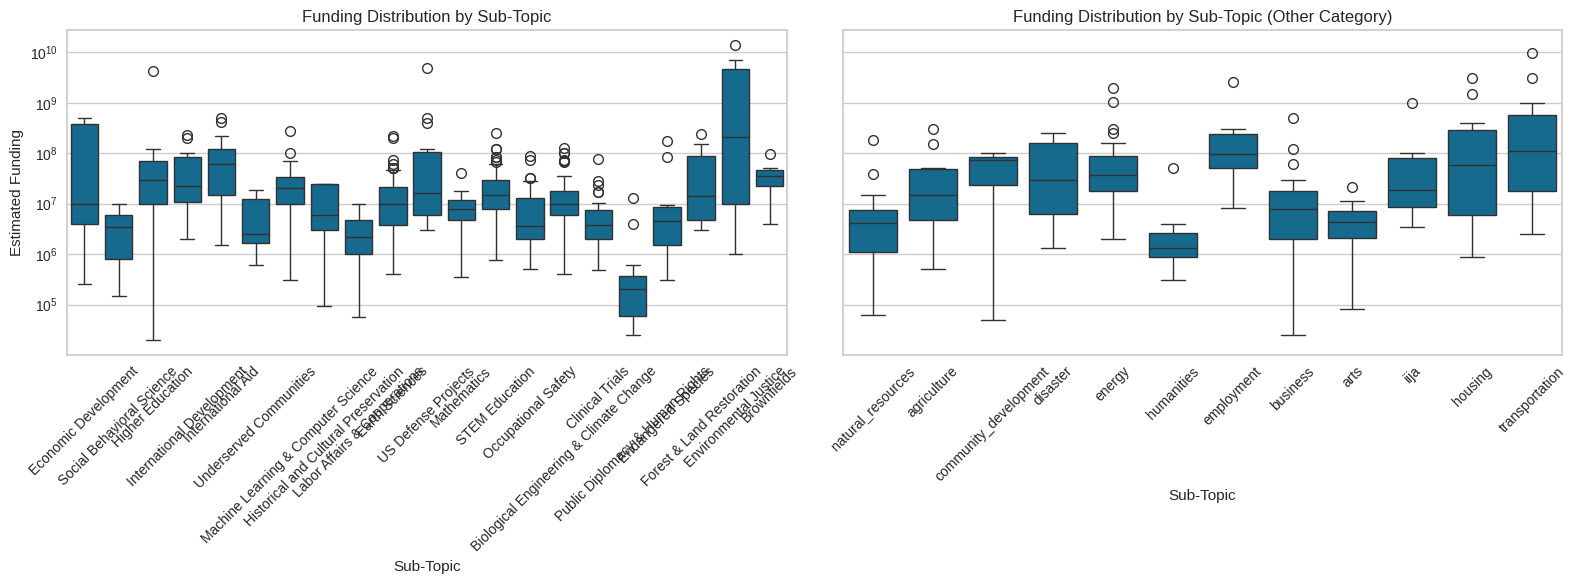

In [196]:
# Filter out missing funding values
details_clean = details.dropna(subset=['estimated_total_program_funding'])
details_clean = details_clean[details_clean['estimated_total_program_funding'] > 0]

# Filter to subtopics with more than 5 remaining grants
subtopics_count = details_clean['sub_topic'].value_counts()
filtered_subtopics = subtopics_count[subtopics_count > 5]
details_clean = details_clean[details_clean['sub_topic'].isin(filtered_subtopics.index)]

# Create a box plot for cluster identified sub topics
top_cats = ['health', 'science', 'environment', 'education', 'other']
details_clean_top_cat = details_clean[details_clean['official_category'].isin(top_cats)]
details_clean_other_cat = details_clean[~details_clean['official_category'].isin(top_cats)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.boxplot(
    data=details_clean_top_cat,
    x='sub_topic',
    y='estimated_total_program_funding',
    ax=axes[0]
)
axes[0].set_title("Funding Distribution by Sub-Topic (Cluster Identified)")
axes[0].set_xlabel("Sub-Topic")
axes[0].set_ylabel("Estimated Funding")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    data=details_clean_other_cat,
    x='sub_topic',
    y='estimated_total_program_funding',
    ax=axes[1]
)

axes[1].set_title("Funding Distribution by Sub-Topic (Assigned Category)")
axes[1].set_xlabel("Sub-Topic")
axes[1].set_ylabel("Estimated Funding")
axes[1].tick_params(axis='x', rotation=45)

plt.yscale('log')
plt.tight_layout()
plt.show()

# **Integrations**

## **1. Grant Profiles x Topic Clusters**

### **Getting Grant Profiles** (Allison's Code)

In [ ]:
grants['expected_awards_num'] = pd.to_numeric(grants['expected_number_of_awards'], errors='coerce')

agency_profile = (grants.groupby('agency_name')
                  .agg(
                      n_opps=('opportunity_id','count'),
                      avg_funding=('estimated_funding','mean'),
                      med_funding=('estimated_funding', 'median'),
                      avg_awards=('expected_awards_num','mean'),
                      med_awards=('expected_awards_num', 'median'),
                      funding_missing_rate=('estimated_funding', lambda s: s.isna().mean())
                  )
                  .reset_index())

agency_profile.sort_values('n_opps', ascending=False).head(10)

# Choosing my Features
features = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

# Create Log Features --> directly into dataframe
features.loc[:, 'log_n_opps'] = np.log1p(features['n_opps'])
features.loc[:, 'log_med_funding'] = np.log1p(features['med_funding'])
features.loc[:, 'log_med_awards'] = np.log1p(features['med_awards'])

# Final Feature Set Before Clustering
features = features[['log_n_opps', 'log_med_funding', 'log_med_awards', 'funding_missing_rate']].copy()

In [ ]:
# KMeans cannot handle NaNs, rows with missing data will be removed for clustering
features.isna().sum().sort_values(ascending=False)
features_clean = features.dropna()

In [ ]:
#Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)

In [ ]:
#Running K-Means & Picking 4 as my k

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

#Attatch Cluster Labels to Agencies
agency_profile_clean = agency_profile.loc[features_clean.index].copy()
agency_profile_clean['cluster'] = clusters


In [ ]:
#Profile the Clusters

cluster_summary = agency_profile_clean.groupby('cluster')[['n_opps',
                                                           'med_funding',
                                                           'med_awards',
                                                           'funding_missing_rate'
                                                           ]].median()

cluster_summary

,n_opps,med_funding,med_awards,funding_missing_rate
cluster,,,,
0,7.0,225000.0,3.0,0.083333
1,24.0,3000000.0,1.0,0.583333
2,11.0,11250000.0,40.0,0.037037
3,145.5,1650000.0,2.0,0.116531


In [ ]:
# Assign descriptive labels for interpretability
cluster_labels = {
    0: "Lower Funding / Smaller Awards",
    1: "Moderate Funding, Few Awards",
    2: "High Funding Agencies",
    3: "High Opportunity Agencies"}

agency_profile_clean['cluster_label'] = agency_profile_clean['cluster'].map(cluster_labels)

In [ ]:
# Keep only what you need
agency_clusters = agency_profile_clean[['agency_name', 'cluster', 'cluster_label']].copy()

# Merge agency cluster back to grants dataframe
grants_with_agency_cluster = grants.merge(
    agency_clusters,
    on='agency_name',
    how='left'
)


### **Merging DataFrames**

In [112]:
merged_df = details.merge(
    grants_with_agency_cluster[['opportunity_id', 'cluster', 'cluster_label']],
    on='opportunity_id',
    how='inner'   # use inner since you only want overlapping rows
)


In [113]:
print("Merged DF size:", merged_df.shape[0])
print("Missing agency clusters:", merged_df['cluster'].isna().sum())


Merged DF size: 1874
Missing agency clusters: 29


In [114]:
merged_df_clean = merged_df.dropna(subset=['cluster'])

print("Original merged size:", merged_df.shape[0])
print("Clean merged size:", merged_df_clean.shape[0])


Original merged size: 1874
Clean merged size: 1845


### **Analysis**

**Grant Opportunity Cluster Description**

*From Allison's Analysis*

**High Funding Agencies Cluster:** mostly high funding along with higher awards, likely major funding agencies.


**Lower Funding / Smaller Awards Cluster:** lower funding and lower awards, probably smaller agencies.


**High Opportunity Agencies Cluster:** mid range funding with not a huge counts, likely for possible specialized grants.


**Moderate Funding, Few Awards Cluster:** its pretty spread across funding levels, but it looks like lower awards so maybe inconsistent funding strategies for this cluster is present.


####**Median Agency Funding in Each Cluster:**

In [115]:
# agency profiles after merge
agency_profile_new = (merged_df_clean.groupby('agency_name')
                  .agg(
                      n_opps=('opportunity_id','count'),
                      avg_funding=('estimated_total_program_funding','mean'),
                      med_funding=('estimated_total_program_funding', 'median'),
                      avg_awards=('expected_number_of_awards','mean'),
                      med_awards=('expected_number_of_awards', 'median'),
                      funding_missing_rate=('estimated_total_program_funding', lambda s: s.isna().mean()),
                      agency_cluster = ('cluster_label', lambda s: s.mode()[0])
                  )
                  .reset_index())

cluster_summary = agency_profile_new.groupby('agency_cluster')[['n_opps',
                                                           'med_funding',
                                                           'med_awards',
                                                           'funding_missing_rate'
                                                           ]].median()

cluster_summary

,n_opps,med_funding,med_awards,funding_missing_rate
agency_cluster,,,,
High Funding Agencies,2.5,60859118.75,31.5,0.0
High Opportunity Agencies,4.0,5425000.00,10.0,0.0
Lower Funding / Smaller Awards,1.0,150000.00,5.0,0.0
"Moderate Funding, Few Awards",2.0,20000000.00,4.5,1.0


**Merged DF Differences for Average Agency Funding in Each Cluster**

**High Funding Agencies Cluster:**
*  median number of opportunities: $11$ --> $2.5$
*  median funding: $11,250,000$ --> $60,859,118.75$
*  median awards: $40$ --> $31.5$

This is still the highest median funding of all the clusters.

**Lower Funding / Smaller Awards Cluster:**
*  median number of opportunities: $7$ --> $1$
*  median funding: $225,000$ --> $150,000$
*  median awards: $3$ --> $5$

This is still the lowest median funding of all the clusters.

**High Opportunity Agencies Cluster:**
*  median number of opportunities: $145$ --> $4$
*  median funding: $1,650,000$ --> $54,250,000$
*  median awards: $2$ --> $10$

The median number of opportunities per agency in this cluster significantly dropped. Agencies with many grants likely were not included in the details dataframe, or many of their grants were excluded.

**Moderate Funding, Few Awards Cluster:**
*  median number of opportunities: $24$ --> $2$
*  median funding: $3,000,000$ --> $20,000,000$
*  median awards: $1$ --> $4.5$

Median Awards in this cluster increased, but moderate funding is still an appropraite categorication of this cluster.

#### **Cluster Counts Comparison**

In [116]:
grants_with_agency_cluster['cluster_label'].value_counts()

,count
cluster_label,
High Opportunity Agencies,59320
"Moderate Funding, Few Awards",9954
High Funding Agencies,2698
Lower Funding / Smaller Awards,2220


In [117]:
merged_df['cluster_label'].value_counts()

,count
cluster_label,
High Opportunity Agencies,1565
"Moderate Funding, Few Awards",197
High Funding Agencies,60
Lower Funding / Smaller Awards,23


**Analysis**

Many grants were lost as a result of limiting analysis to the details dataset, which can account for the differences seen above. Using the detail dataset is necessary for category and sub-topic analysis, as the grants dataset does not have categorical information. The information gathered on agencies from the larger grants dataset is more informative to how agencies perform, so we can leverage that knowledge and apply it to the smaller details dataset.

#### **Grant Medians by Cluster**

In [122]:
merged_df['agency_cluster'] = merged_df['cluster_label']

grant_summary = merged_df.groupby('agency_cluster').agg(median_funding = ('estimated_total_program_funding','median'),
                                                         avg_funding = ('estimated_total_program_funding','mean'),
                                                         median_awards = ('expected_number_of_awards','median'),
                                                         avg_awards = ('expected_number_of_awards','mean'),
                                                         n_opps = ('opportunity_id','count'))
grant_summary

,median_funding,avg_funding,median_awards,avg_awards,n_opps
agency_cluster,,,,,
High Funding Agencies,42700000.0,2.438762e+08,30.5,21123.916667,60
High Opportunity Agencies,8570000.0,1.333189e+08,12.0,49.990632,1565
Lower Funding / Smaller Awards,175000.0,4.171111e+06,5.0,14.526316,23
"Moderate Funding, Few Awards",10000000.0,4.337482e+07,5.0,119.413043,197


**Analysis**

Looking at the grants overall, rather than the median per agency, we can see the cluster themes persist.

#### **What are the Topics that Each Grant Cluster Funds?**

In [ ]:
merged_df['agency_cluster'] = merged_df['cluster_label']

High_Funding_Agencies = merged_df[merged_df['agency_cluster'] == 'High Funding Agencies']
High_Opportunity_Agencies = merged_df[merged_df['agency_cluster'] == 'High Opportunity Agencies']
Lower_Funding_Smaller_Awards = merged_df[merged_df['agency_cluster'] == 'Lower Funding / Smaller Awards']
Moderate_Funding_Few_Awards = merged_df[merged_df['agency_cluster'] == 'Moderate Funding, Few Awards']

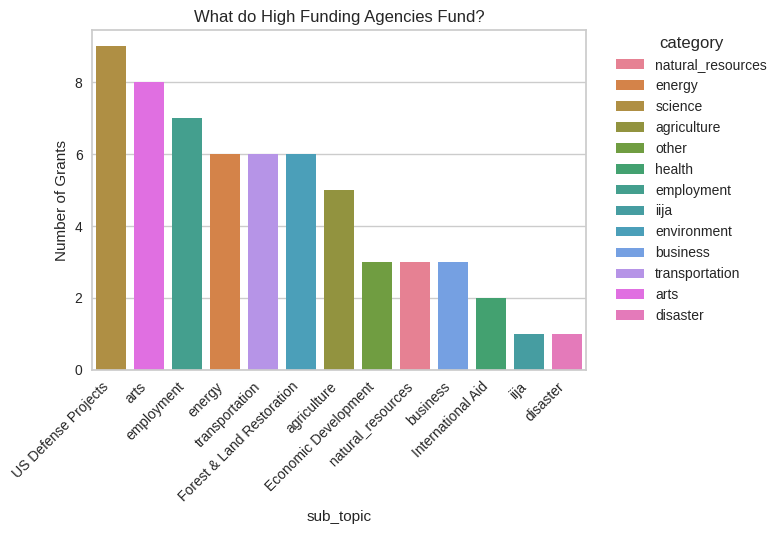

In [146]:
high_fund_order = High_Funding_Agencies['sub_topic'].value_counts().index

count_plot = sns.countplot(
    data=High_Funding_Agencies,
    x='sub_topic',
    hue='official_category',
    order=high_fund_order
)
plt.title("What do High Funding Agencies Fund?")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.legend(
    title='category',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
plt.tight_layout()
plt.show()

**Analysis**

Grants within the high funding category mostly fund US Defense Project, arts, and employment. However, we only have 60 grants in this agency cluster, so results may be skewed. US defense projects and employment makes sense as a category for high funding grants, but art grants is suprising to see.

US Defense, employment, transportation, International Aid appear in this agency cluster as well as the sub-topics with the highest overall average funding. Environmental Justice, Housing, and Community development are notibly missing from this category. Perhaps the agencies funding those grants typically fund smaller grants but had a few larger grants that lead to their apperance in the top 5 highest funding topics.

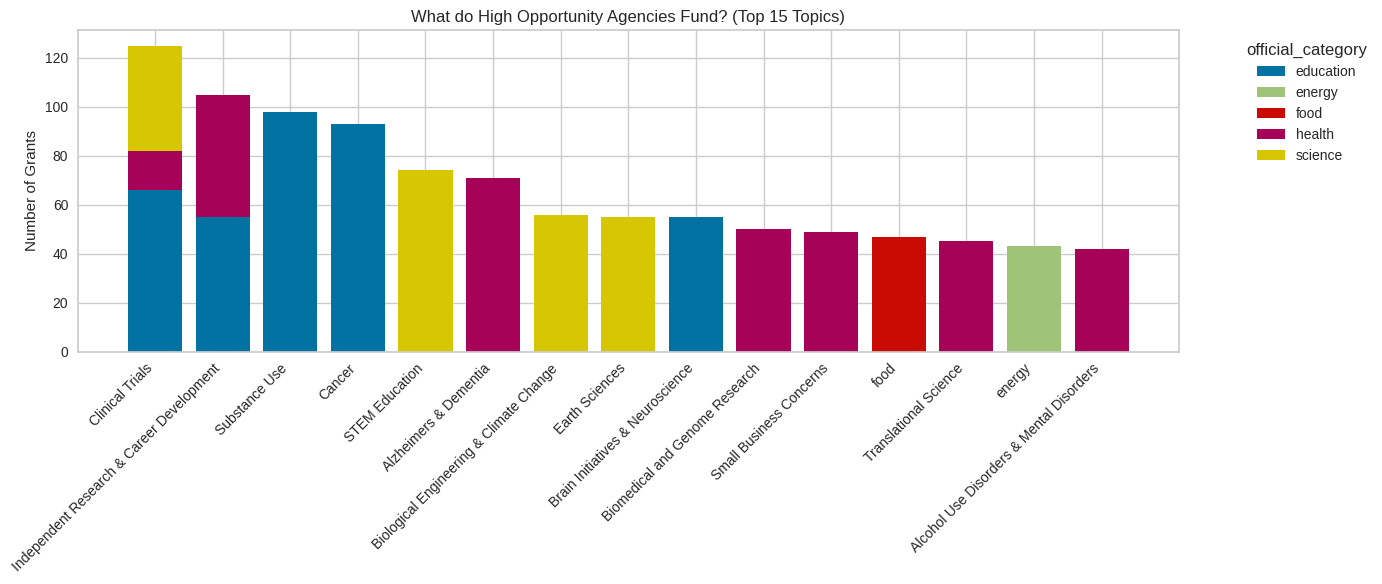

In [145]:
order = High_Opportunity_Agencies['sub_topic'].value_counts().index

top_15 = High_Opportunity_Agencies[High_Opportunity_Agencies['sub_topic'].isin(order[:15])]

count_data = (
    top_15
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
)
count_data = count_data.loc[order[:15]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(count_data))

for category in count_data.columns:
    plt.bar(
        count_data.index,
        count_data[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data[category]

plt.title("What do High Opportunity Agencies Fund? (Top 15 Topics)")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

**Analysis**

For High Opportunity Agencies (i.e, agencies that offer many grants), education is the top broad category. Within sub-topics, these agencies fund clinical trials, independent research, substance use (within the education category), and cancer (within the the education category).

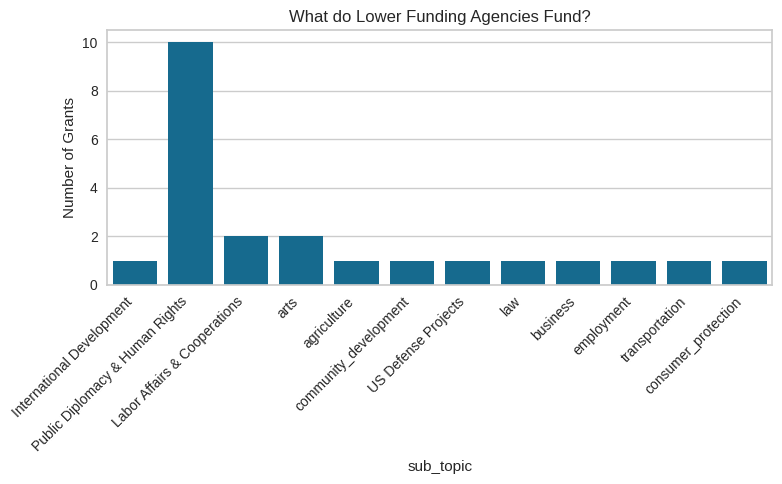

In [147]:
fig, ax = plt.subplots(figsize=(8, 5))

count_plot = sns.countplot(
    data=Lower_Funding_Smaller_Awards,
    x='sub_topic'
)
plt.title("What do Lower Funding Agencies Fund?")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

Lower Funding Agencies (i.e, agencies that offer small grants), primarily fund public diplomacy and human rights, followed by arts and labor affairs. Thes are often over looked categories, so these results align with intuition. However, we have a smaller set of grants in this category, so results may be skewed.

Public Diplocy also appears in the lowest average funding topics overall, so its prominance here is aligned.

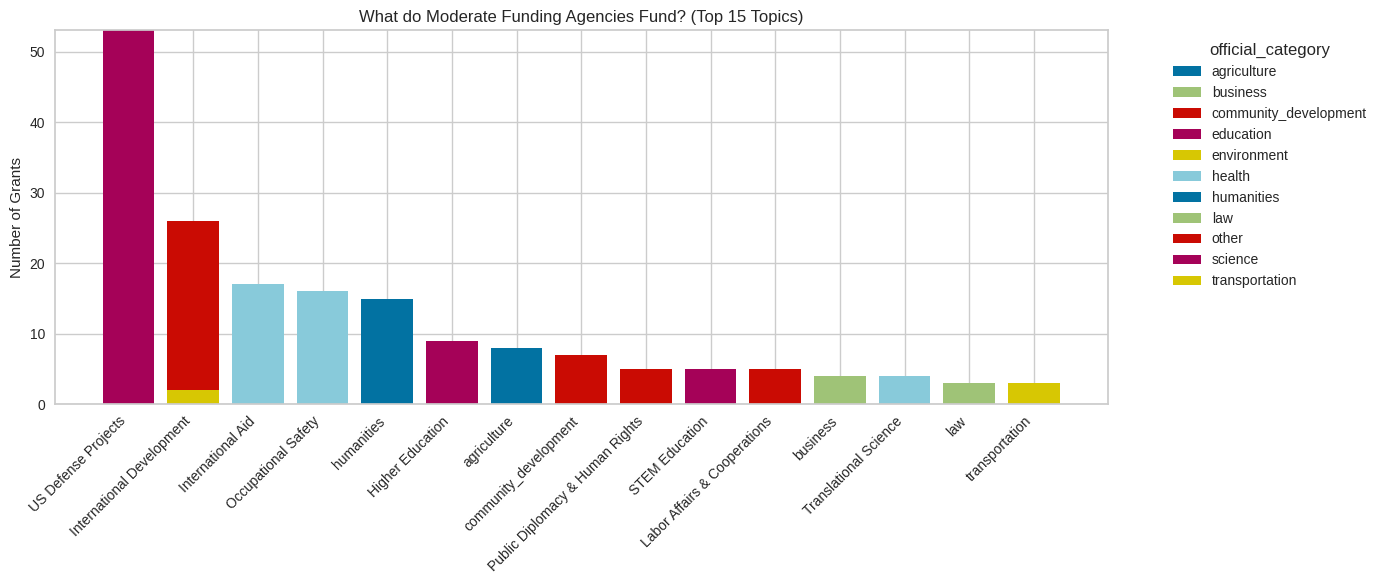

In [152]:
moderate_order = Moderate_Funding_Few_Awards['sub_topic'].value_counts().index

moderate_top_15 = Moderate_Funding_Few_Awards[Moderate_Funding_Few_Awards['sub_topic'].isin(moderate_order[:15])]

moderate_data = (
    moderate_top_15
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
)
moderate_data = moderate_data.loc[moderate_order[:15]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(moderate_data))

for category in moderate_data.columns:
    plt.bar(
        moderate_data.index,
        moderate_data[category],
        bottom=bottom,
        label=category
    )
    bottom += moderate_data[category]

plt.title("What do Moderate Funding Agencies Fund? (Top 15 Topics)")
plt.ylabel("Number of Grants")
plt.xticks(rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

**Analysis**

Moderate Funding Agencies primarily fund US Defense Project, International Development, International Aid, and Occupational Safety. These sub-topics are mostly across the broad categories of Science, Other, and Health. This analysis again shows the prominance of US defense in grants overall. International related grants have not shown up in other agency clusters with as much prominace, indicating they are still a main theme of grant funding overall but have slightly lower funding patterns than US defense projects.

##**2. Grant Eligibility x Topic Clusters**

### **Getting Eligibility Clusters** (Sambisha's Code)

In [161]:
# Identify eligibility columns
elig_cols = [col for col in details.columns if col.startswith("eligibility_")]

# Select relevant columns from grants: opportunity_id, estimated_funding, agency_name
grants_subset = grants[['opportunity_id', 'estimated_funding', 'agency_name']]

# Merge with eligibility data
merged = details.merge(grants_subset, on='opportunity_id', how='left')

# Extract eligibility matrix for clustering
X_elig = merged[elig_cols]

In [162]:
!pip install kmodes

from kmodes.kmodes import KModes

# Run K-Modes with 3 clusters (same number as K-Means for comparison)
km = KModes(n_clusters=3, init='Huang', n_init=5, random_state=42)
km_labels = km.fit_predict(X_elig)

# Add labels to merged dataset
merged['kmodes_cluster'] = km_labels

### **Merging DataFrames**

In [166]:
eligibility_merged_df = details.merge(
    merged[['opportunity_id', 'kmodes_cluster']],
    on='opportunity_id',
    how='inner'   # use inner since you only want overlapping rows
)

In [167]:
eligibility_merged_df['kmodes_cluster'].isna().sum()

np.int64(0)

### **Analysis**

**Cluster Descriptions** *From Sambisha*

**Cluster 0 — Broad Institutional Eligibility** Mostly driven by NIH (861 grants), with smaller contributions from CDC‑ERA, Commerce, AHRQ, and Fish & Wildlife. These agencies typically fund structured, institution‑focused programs with wide organizational eligibility.

**Cluster 1 — Minimal/Unspecified Eligibility** Led by the National Science Foundation (160) and **NIH (106), **along with NASA, EPA, and Commerce. These agencies often publish opportunities where eligibility is less explicitly defined.

**Cluster 2 — Fully Unrestricted Eligibility** Dominated by NSF (116), with strong representation from the Army (USAMRAA), USAID, NETL, and the Golden Field Office. These agencies frequently issue open‑access opportunities intended for broad applicant pools.

In [168]:
# elibilitity cluster mapping
elig_cluster_labels = {
    0: "Broad Institutional Eligibility",
    1: "Minimal/Unspecified Eligbility",
    2: "Fully Unrestricted Eligibility"}

eligibility_merged_df['eligibility_cluster'] = eligibility_merged_df['kmodes_cluster'].map(elig_cluster_labels)

In [169]:
eligibility_cross_tab = pd.crosstab(
    eligibility_merged_df['sub_topic'],
    eligibility_merged_df['eligibility_cluster'],
    normalize='columns'
)

print(eligibility_cross_tab)


eligibility_cluster                             Broad Institutional Eligibility  \
sub_topic                                                                         
Alcohol Use Disorders & Mental Disorders                               0.045802   
Alzheimers & Dementia                                                  0.076336   
Biological Engineering & Climate Change                                0.000000   
Biomedical and Genome Research                                         0.038168   
Brain Initiatives & Neuroscience                                       0.057797   
Brownfields                                                            0.000000   
Cancer                                                                 0.100327   
Climate Change                                                         0.000000   
Clinical Trials                                                        0.079607   
Common Fund                                                            0.041439   
Eart

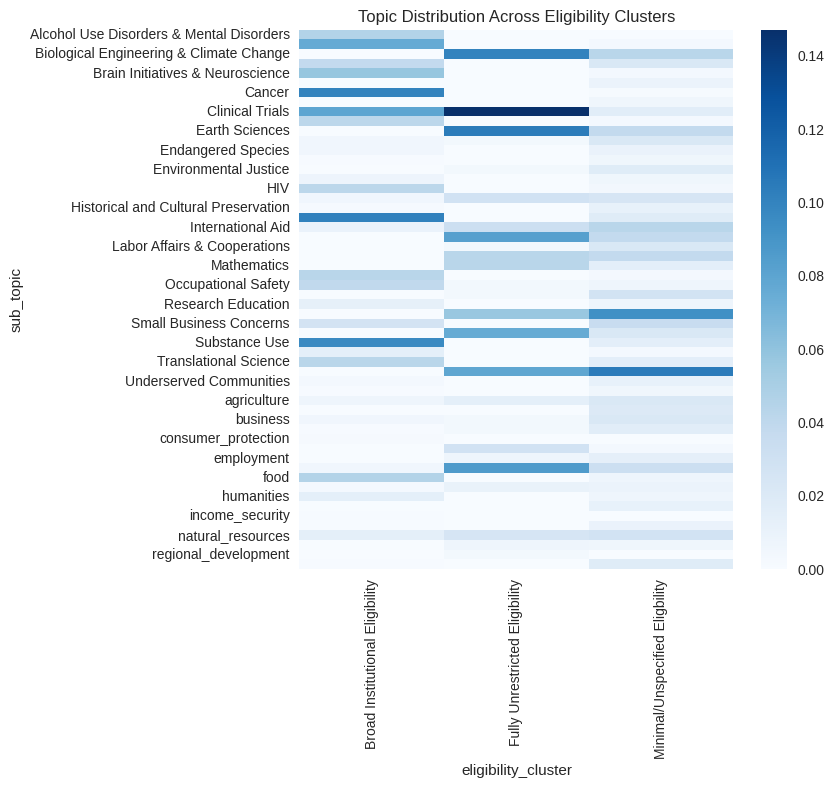

In [170]:
#Heatmap
plt.figure(figsize=(7, 7))
sns.heatmap(eligibility_cross_tab, annot=False, cmap='Blues')
plt.title("Topic Distribution Across Eligibility Clusters")
plt.show()


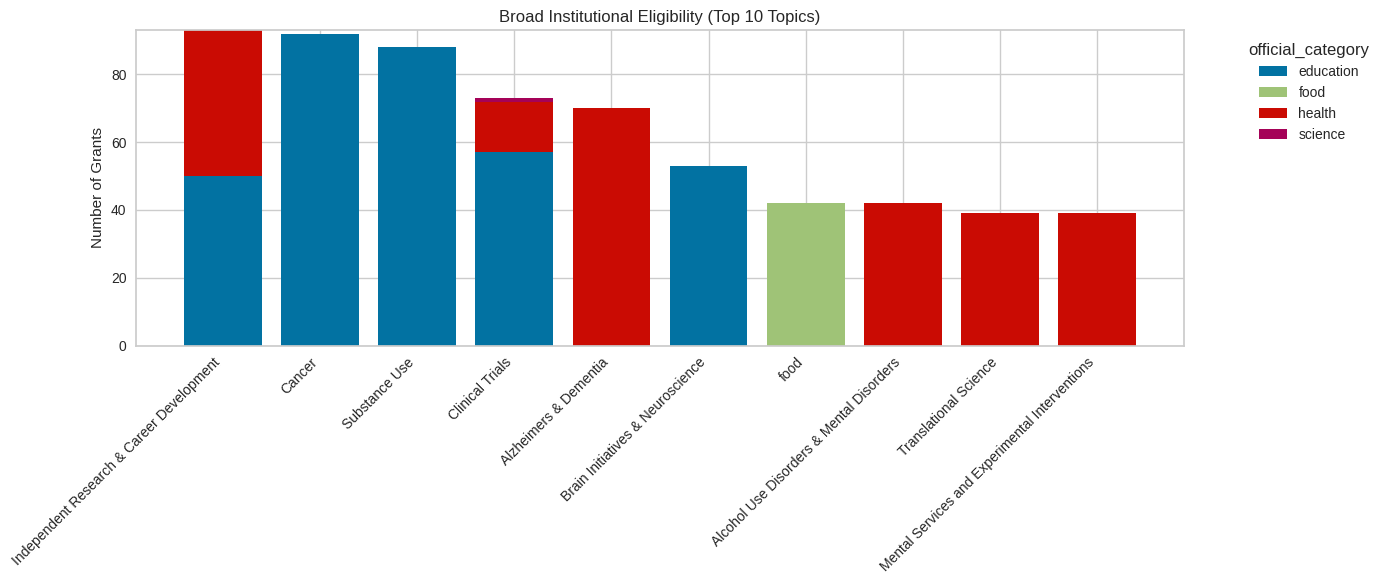

In [182]:
# Graph Topics per Eligibility Cluster
broad_cluster = eligibility_merged_df[eligibility_merged_df['eligibility_cluster'] == "Broad Institutional Eligibility"]
minimal_cluster = eligibility_merged_df[eligibility_merged_df['eligibility_cluster'] == "Minimal/Unspecified Eligbility"]
unrestricted_cluster = eligibility_merged_df[eligibility_merged_df['eligibility_cluster'] == 'Fully Unrestricted Eligibility']

order_0 = broad_cluster['sub_topic'].value_counts().index

top_10_broad = broad_cluster[broad_cluster['sub_topic'].isin(order_0[:10])]

count_data_broad = (
    top_10_broad
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_0[:10]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(count_data_broad))

for category in count_data_broad.columns:
    plt.bar(
        count_data_broad.index,
        count_data_broad[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_broad[category]

plt.title("Broad Institutional Eligibility (Top 10 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


**Analysis**

For the Broad Institutional Eligibility Cluster, which are typically grants that fund structured, institution‑focused programs with wide organizational eligibility, Independent Research, Cancer, and Sustance use are the top 3 sub-topics. Education and Health are the primary broad categories.

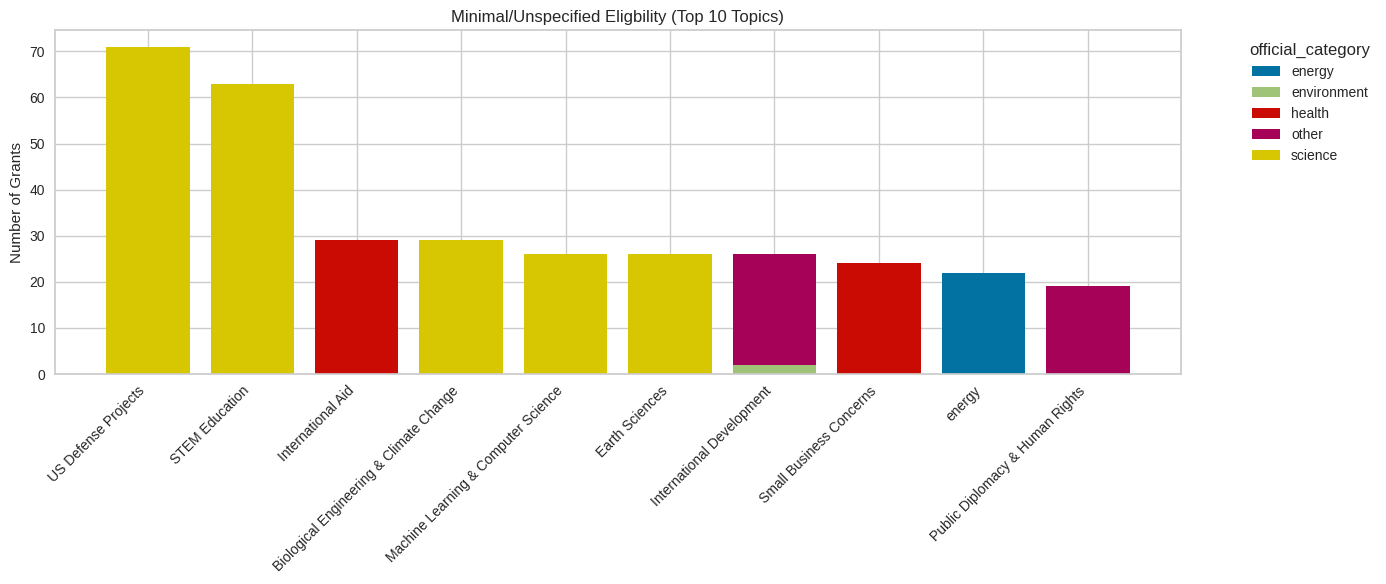

In [183]:
order_1 = minimal_cluster['sub_topic'].value_counts().index

top_10_min = minimal_cluster[minimal_cluster['sub_topic'].isin(order_1[:10])]

count_data_min = (
    top_10_min
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_1[:10]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(count_data_min))

for category in count_data_min.columns:
    plt.bar(
        count_data_min.index,
        count_data_min[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_min[category]

plt.title("Minimal/Unspecified Eligbility (Top 10 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

**Analysis**

Cluster 1 — Minimal/Unspecified Eligibility: These agencies often publish opportunities where eligibility is less explicitly defined.

Science is the main broad category for unspecified eligibility agency clusters. US Defense Projects and STEM education are the subtopics that dominate this cluster.

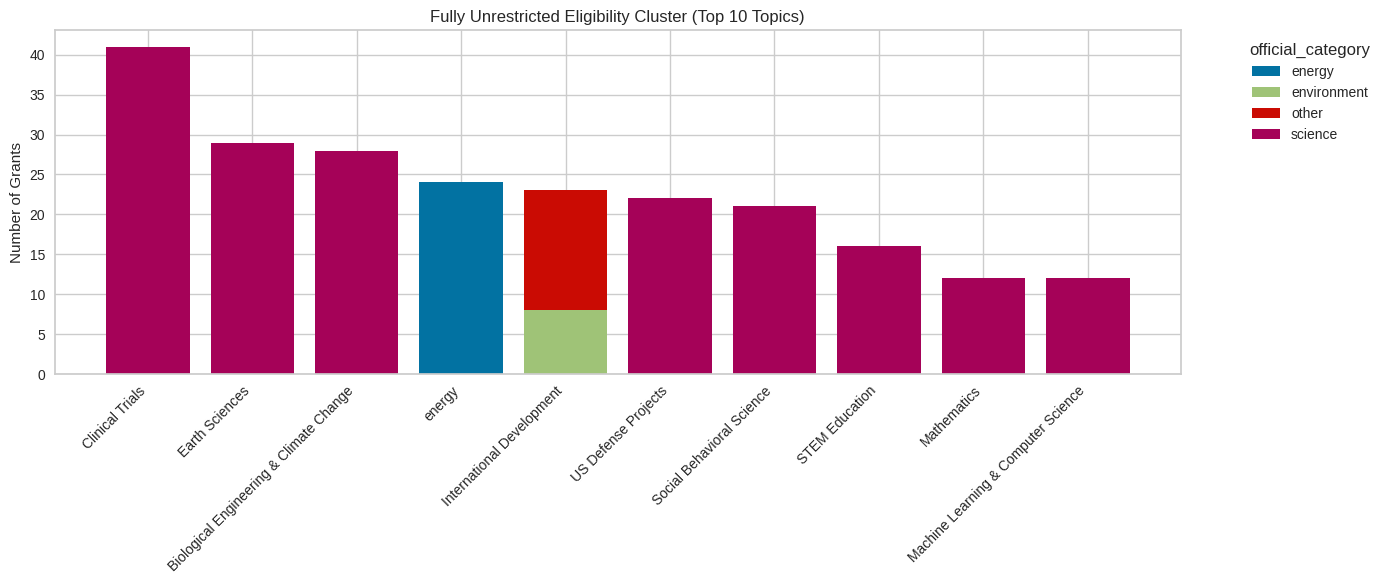

In [184]:
order_2 = unrestricted_cluster['sub_topic'].value_counts().index


top_10_unres = unrestricted_cluster[unrestricted_cluster['sub_topic'].isin(order_2[:10])]

count_data_unres = (
    top_10_unres
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_2[:10]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(count_data_unres))

for category in count_data_unres.columns:
    plt.bar(
        count_data_unres.index,
        count_data_unres[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_unres[category]

plt.title("Fully Unrestricted Eligibility Cluster (Top 10 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

**Analysis**

Cluster 2 — Fully Unrestricted Eligibility: These agencies frequently issue open‑access opportunities intended for broad applicant pools.

Science also dominates this cluster, but Clinical Trials, Earth Sciences, and Climate Change appear to typically have more open opportunities with broader applicant pools.

##**3. Grant Era x Topic Clusters**

###**Getting Grant Era Clusters**
*From Anna's Code*

In [226]:
grants_original = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv"
)

details_original = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv"
)

# Merge the tables
merged = grants_original.merge(details_original, on='opportunity_id', how='inner')

# Just create posted_year for checking temporal coverage
merged['posted_year'] = pd.to_datetime(merged['posted_date_y']).dt.year

# Fill Estimated Funding NaNs with 0
merged['estimated_funding'] = merged['estimated_funding'].fillna(0)

# log transform estimated funding to compress extreme values
merged['estimated_funding'] = np.log1p(merged['estimated_funding'])


/tmp/ipython-input-2245962282.py:1: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants_original = pd.read_csv(


In [263]:
merged.shape

(2000, 86)

In [227]:
top_10_agencies = (merged['agency_name_x'].value_counts().head(10).index)

merged['agency_simplified'] = merged['agency_name_x'].apply(
    lambda x: x if x in top_10_agencies else 'Other')

In [228]:
cols_to_keep = (
    ['estimated_funding', 'posted_year', 'agency_simplified'] +
    [col for col in merged.columns
     if col.startswith('eligibility_')] +
    [col for col in merged.columns
     if col.startswith('category_') and col != 'category_explanation']
)

df_cluster = merged[cols_to_keep].copy()

In [229]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_cluster[['estimated_funding', 'posted_year']] = scaler.fit_transform(
    df_cluster[['estimated_funding', 'posted_year']]
)

# Convert agency to string
df_cluster['agency_simplified'] = df_cluster['agency_simplified'].astype(str)

# Convert all boolean columns to string
bool_cols = df_cluster.select_dtypes(include='bool').columns
df_cluster[bool_cols] = df_cluster[bool_cols].astype(str)

In [230]:
!pip install kmodes

from kmodes.kprototypes import KPrototypes

# First two columns are numeric (funding, year)
categorical_cols = list(range(2, df_cluster.shape[1]))

kproto = KPrototypes(
    n_clusters=4,
    init='Cao', # This method initializes the centroids based on a distance and density-based approach, rather than picking random data points
    n_init=5,
    verbose=2,
    random_state=42
)

clusters = kproto.fit_predict(
    df_cluster,
    categorical=categorical_cols
)

df_cluster['cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 116, ncost: 4604.051319851276
Run: 1, iteration: 2/100, moves: 16, ncost: 4592.3120958834215
Run: 1, iteration: 3/100, moves: 5, ncost: 4591.46820059398
Run: 1, iteration: 4/100, moves: 4, ncost: 4590.777922709327
Run: 1, iteration: 5/100, moves: 5, ncost: 4590.498718307751
Run: 1, iteration: 6/100, moves: 25, ncost: 4493.639966865642
Run: 1, iteration: 7/100, moves: 247, ncost: 3853.5314867939337
Run: 1, iteration: 8/100, moves: 154, ncost: 3461.7885524459443
Run: 1, iteration: 9/100, moves: 5, ncost: 3460.959783800183
Run: 1, iteration: 10/100, moves: 1, ncost: 3460.9086494485755
Run: 1, iteration: 11/100, moves: 0, ncost: 3460.9086494485755
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 803, ncost: 3487.1990978685767
Run: 2, iterati

In [231]:
# --- STEP 1: CREATE A READABLE VERSION OF DATA ---
df_readable = df_cluster.copy()

# Reverse scaling and log math to get real numbers
df_readable[['estimated_funding', 'posted_year']] = scaler.inverse_transform(
    df_readable[['estimated_funding', 'posted_year']]
)
df_readable['estimated_funding'] = np.expm1(df_readable['estimated_funding'])

df_readable.head()

,estimated_funding,posted_year,agency_simplified,eligibility_individuals,eligibility_state_governments,eligibility_county_governments,eligibility_independent_school_districts,eligibility_city_or_township_governments,eligibility_special_district_governments,eligibility_native_american_tribal_governments_federally_recognized,...,category_income_security,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other,cluster
0,100000000.0,2023.0,Environmental Protection Agency,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2
1,0.0,2023.0,Other,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,3
2,0.0,2023.0,Other,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,3
3,2500000.0,2023.0,Other,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,2
4,7500000.0,2023.0,National Science Foundation,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,2


### **Merge DataFrames**

In [269]:
details['posted_year'] = pd.to_datetime(details['posted_date']).dt.year

In [270]:
# Copy to avoid modifying originals
details_merge = details.copy()
df_readable_merge = df_readable.copy()

# Rename columns to match
details_merge = details_merge.rename(columns={
    'estimated_total_program_funding': 'estimated_funding'
})

# Ensure numeric funding matches type
details_merge['estimated_funding'] = pd.to_numeric(details_merge['estimated_funding'], errors='coerce')
df_readable_merge['estimated_funding'] = pd.to_numeric(df_readable_merge['estimated_funding'], errors='coerce')

# Ensure posted_year type matches
details_merge['posted_year'] = details_merge['posted_year'].astype('Int64')
df_readable_merge['posted_year'] = df_readable_merge['posted_year'].astype('Int64')


In [271]:
#Create agency_simplified in details to match df_readable
top_agencies = df_readable_merge['agency_simplified'].unique()

details_merge['agency_simplified'] = details_merge['agency_name'].apply(
    lambda x: x if x in top_agencies else 'other'
)


In [272]:
cat_cols = [c for c in df_readable_merge.columns if c.startswith('category_')]
df_readable_merge['official_category'] = df_readable_merge[cat_cols].idxmax(axis=1).str.replace('category_', '')

In [273]:
elig_cols = [c for c in df_readable_merge.columns if c.startswith('eligibility_')]
df_readable_merge['eligibility_type'] = df_readable_merge[elig_cols].idxmax(axis=1).str.replace('eligibility_', '')

In [274]:
details_merge['eligibility_type'] = details_merge[elig_cols].idxmax(axis=1).str.replace('eligibility_', '')

In [281]:
# Rounding Estimated Funding
details_merge['estimated_funding'] = (
    details_merge['estimated_funding']
    .round(-1)
    .astype('Int64')
)

df_readable_merge['estimated_funding'] = (
    df_readable_merge['estimated_funding']
    .round(-1)
    .astype('Int64')
)

# Round Posted Year
details_merge['posted_year'] = details_merge['posted_year'].round().astype('Int64')
df_readable_merge['posted_year'] = df_readable_merge['posted_year'].round().astype('Int64')

In [282]:
# Columns to merge on
merge_cols = [
    'estimated_funding',
    'eligibility_type',
    'posted_year',
    'agency_simplified',
    'official_category'
]

# Merge dfs
era_merged_df = details_merge.merge(
    df_readable_merge[merge_cols + ['cluster']],
    on=merge_cols,
    how='inner'
)

In [283]:
era_mapping = {
    0:'Modern Healthcare & Institutional Infrastructure Era',
    1:'Pre-Expansion Historical Baseline',
    2:'High-Investment Science & STEM Innovation',
    3:'Modern Non-Established-Funding Initiatives'
}

era_merged_df['era_cluster'] = era_merged_df['cluster'].map(era_mapping)

In [284]:
era_merged_df.shape

(653, 75)

In [285]:
era_merged_df['era_cluster'].value_counts()

,count
era_cluster,
High-Investment Science & STEM Innovation,563
Modern Healthcare & Institutional Infrastructure Era,55
Pre-Expansion Historical Baseline,19
Modern Non-Established-Funding Initiatives,16


**Analysis**

Since merging our data frames resulted in the loss of several rows, further analysis may be slightly skewed.

**Cluster Descriptions:**

*From Anna's Analysis*

**Cluster 0: The Modern Healthcare & Institutional Infrastructure Era (2018–2023).** This is the largest cluster **(956 grants)**, heavily concentrated in 2022 and dominated by the NIH (861 grants), with some CDC. The average award is over 1.2M dollars, which looks to be skewed up by some high amounts as the median is 0. It is defined by 100% eligibility for state and county governments and is overwhelmingly focused on Health (94%) and Education (40%), marking a highly specialized era of modern social infrastructure.

**Cluster 1: The Pre-Expansion Historical Baseline (2004–2018).** Representing an earlier era with a "typical year" of 2014, this smaller cluster **(81 grants)** reflects a more fragmented funding landscape. Interestingly, it features a massive average funding amount (80.5M) contrasted against a tiny 20k median, indicating a few extreme "mega-grants" among many small ones. Science (40%) is the lead category, but "Other" categories are high (22%), showing less thematic specialization than modern clusters.

**Cluster 2: High-Investment Science & STEM Innovation (2018–2023).** This cluster **(559 grants)** represents the "heavy hitters" of modern federal research, with a typical year of 2023 and a massive median funding of 10,000,000 dollars. Driven by the NSF (National Science Foundation) and the Department of the Army, it focuses primarily on Science (52%) and Environment (12%). It is characterized by high funding, reflecting large-scale federal investment in STEM and national security innovation.

**Cluster 3: Modern Non-Established-Funding Initiatives (2018–2023).** With **404 grants** and a typical year of 2023, this cluster is unique for having 0 dollars in both median and average funding, the grants that have "$0" or NA entered in estimated_funding, meaning grants in earlier development or without established/decided upon funding. At 404 grants, these are less so outliers and moreso a pattern to pay attention to. This cluster features a diverse mix of NIH, NASA, and "Other" agencies, with a blend of Science (39%) and Health (32%) categories, representing the diversification of federal grant formats in the current decade.

In [286]:
era_merged_df.groupby('era_cluster')['sub_topic'].value_counts()

era_cluster                                           sub_topic                                
High-Investment Science & STEM Innovation             STEM Education                               129
                                                      Biological Engineering & Climate Change       75
                                                      Clinical Trials                               57
                                                      Earth Sciences                                48
                                                      Machine Learning & Computer Science           48
                                                      Environmental Education                       40
                                                      Social Behavioral Science                     32
                                                      Mathematics                                   24
                                                      Environmental Justice                         16
                                                      energy                                        16
                                                      Endangered Species                             9
                                                      US Defense Projects                            8
                                                      Brownfields                                    7
                                                      natural_resources                              7
                                                      Climate Change                                 6
                                                      business                                       6
                                                      Underserved Communities                        5
                                                      Water                                          5
                                                      Higher Education                               4
                                                      Occupational Safety                            4
                                                      International Aid                              3
                                                      disaster                                       3
                                                      iija                                           3
                                                      Economic Development                           2
                                                      Forest & Land Restoration                      2
                                                      Historical and Cultural Preservation           2
                                                      International Development                      2
Modern Healthcare & Institutional Infrastructure Era  Occupational Safety                           28
                                                      natural_resources                             10
                                                      Brain Initiatives & Neuroscience               5
                                                      Independent Research & Career Development      4
                                                      Endangered Species                             2
                                                      Alzheimers & Dementia                          1
                                                      Clinical Trials                                1
                                                      Forest & Land Restoration                      1
                                                      Research Education                             1
                                                      Small Business Concerns                        1
                                                      food                                   

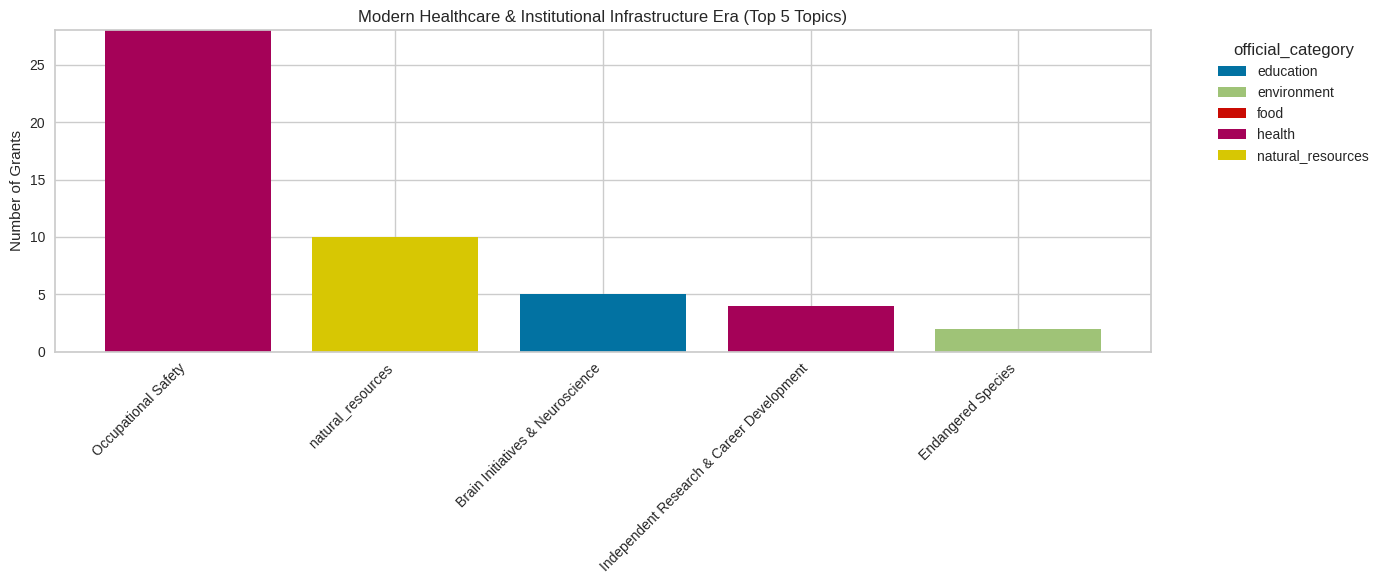

In [291]:
# Graph Topics per Era Cluster
cluster_0 = era_merged_df[era_merged_df['cluster'] == 0]
cluster_1 = era_merged_df[era_merged_df['cluster'] == 1]
cluster_2 = era_merged_df[era_merged_df['cluster'] == 2]
cluster_3 = era_merged_df[era_merged_df['cluster'] == 3]


order_0 = cluster_0['sub_topic'].value_counts().index

top_5_0 = cluster_0[cluster_0['sub_topic'].isin(order_0[:5])]

count_data_0 = (
    top_10_0
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_0[:5]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(count_data_0))

for category in count_data_0.columns:
    plt.bar(
        count_data_0.index,
        count_data_0[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_0[category]

plt.title("Modern Healthcare & Institutional Infrastructure Era (Top 5 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

**Analysis**

The modern healthcare and institutional infrastructure era has a larger variety of grant sub cateogries than the other eras. Occupational Saftey grants, within the broader health category, lead this era, followed by natural resources and neuroscience. These are more advanced topics than appear in the pre-expansion era.

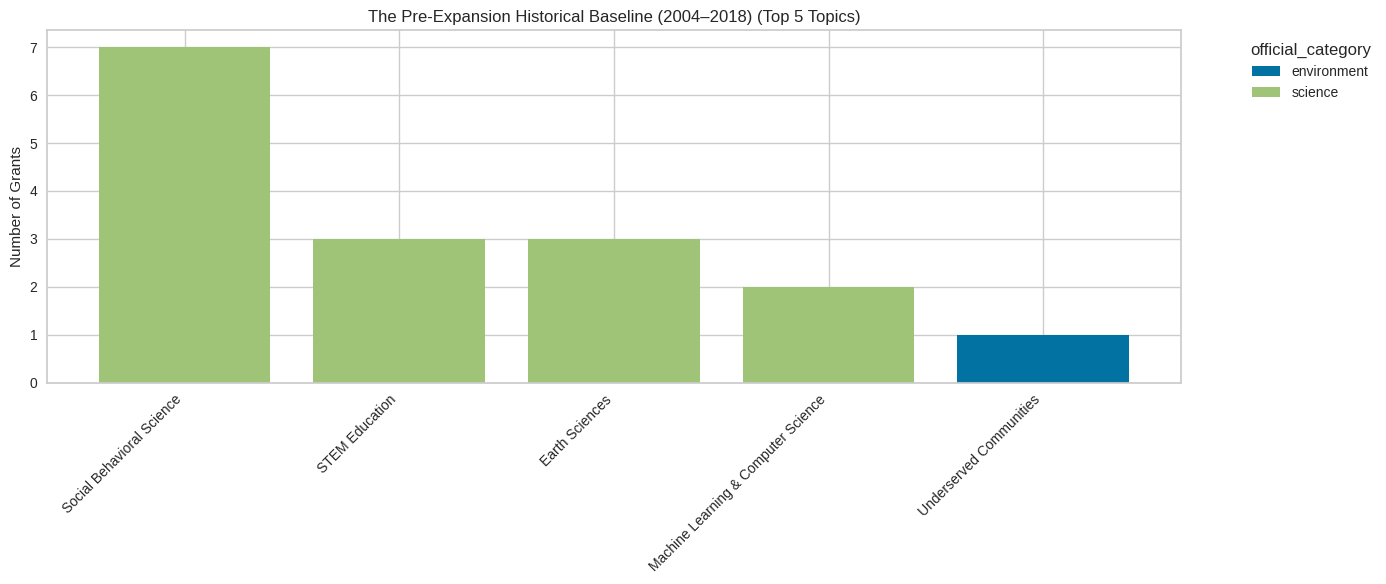

In [293]:
order_1 = cluster_1['sub_topic'].value_counts().index

top_5_1 = cluster_1[cluster_1['sub_topic'].isin(order_1[:5])]

count_data_1 = (
    top_5_1
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_1[:5]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(count_data_1))

for category in count_data_1.columns:
    plt.bar(
        count_data_1.index,
        count_data_1[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_1[category]

plt.title("The Pre-Expansion Historical Baseline (2004–2018) (Top 5 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

**Analysis**

The Pre-Expansion Hisotrical Baseline Cluster had few remaining grants to analyze, but amoung those Science leads this era. Social Behavioral Sciences have the most grants in this category.

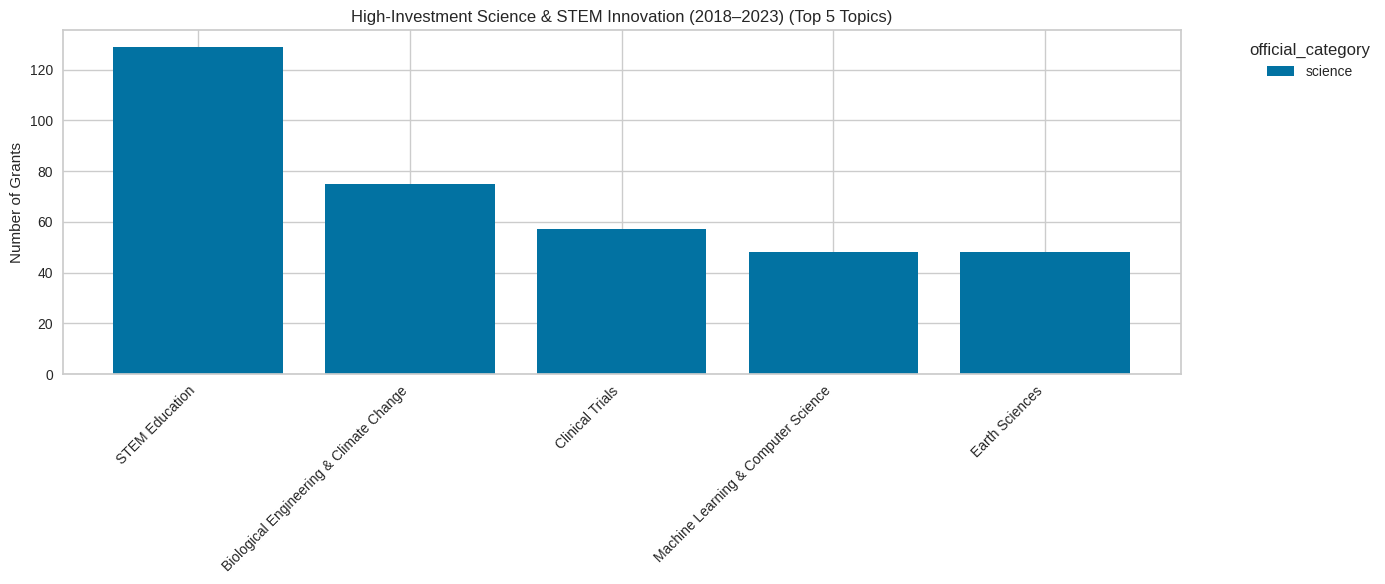

In [294]:
order_2 = cluster_2['sub_topic'].value_counts().index

top_5_2 = cluster_2[cluster_2['sub_topic'].isin(order_2[:5])]

count_data_2 = (
    top_5_2
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_2[:5]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(count_data_2))

for category in count_data_2.columns:
    plt.bar(
        count_data_2.index,
        count_data_2[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_2[category]

plt.title("High-Investment Science & STEM Innovation (2018–2023) (Top 5 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

**Analysis**

This era cluster had the largest amount of remaining grants after merging. All top 5 sub-topics were the broader science category, with STEM education having the most grants, followed by Biological Engineering & Climate Change. Given this era's focus on science, these topics make sense.

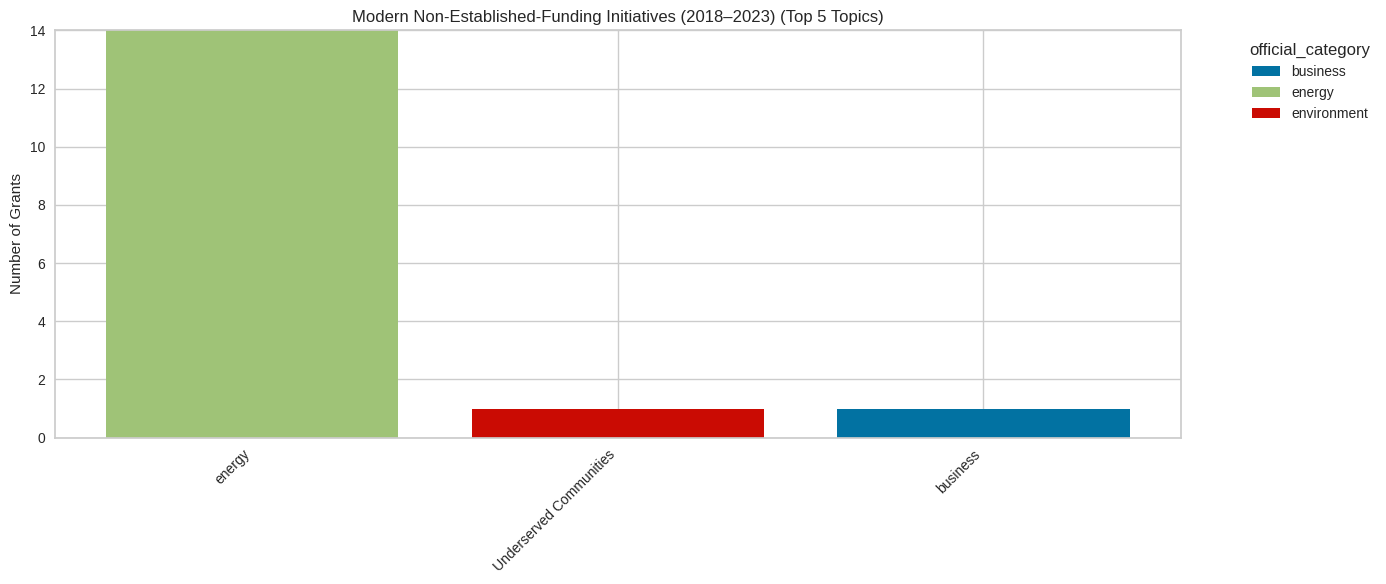

In [295]:
order_3 = cluster_3['sub_topic'].value_counts().index

top_5_3 = cluster_3[cluster_3['sub_topic'].isin(order_3[:5])]

count_data_3 = (
    top_5_3
    .groupby(['sub_topic', 'official_category'])
    .size()
    .unstack(fill_value=0)
).loc[order_3[:5]]

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(count_data_3))

for category in count_data_3.columns:
    plt.bar(
        count_data_3.index,
        count_data_3[category],
        bottom=bottom,
        label=category
    )
    bottom += count_data_3[category]

plt.title("Modern Non-Established-Funding Initiatives (2018–2023) (Top 5 Topics)")
plt.ylabel("Number of Grants")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

plt.legend(
    title="official_category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

**Analysis**

While few grants were available to this analysis, Energy grants lead the Non-Established Funding Initiative Era.

### **Sub Topic Time Series Analysis**

In [305]:
# Limit to Top Sub-topics
top_topics = (
    details['sub_topic']
    .value_counts()
    .head(10)
    .index
)

df_top = details[details['sub_topic'].isin(top_topics)]

In [306]:
# Count aggregation
time_counts = (
    df_top
    .groupby(['posted_year', 'sub_topic'])
    .size()
    .reset_index(name='grant_count')
)

# Funding Aggregation
time_funding = (
    df_top
    .groupby(['posted_year', 'sub_topic'])['estimated_total_program_funding']
    .sum()
    .reset_index()
)


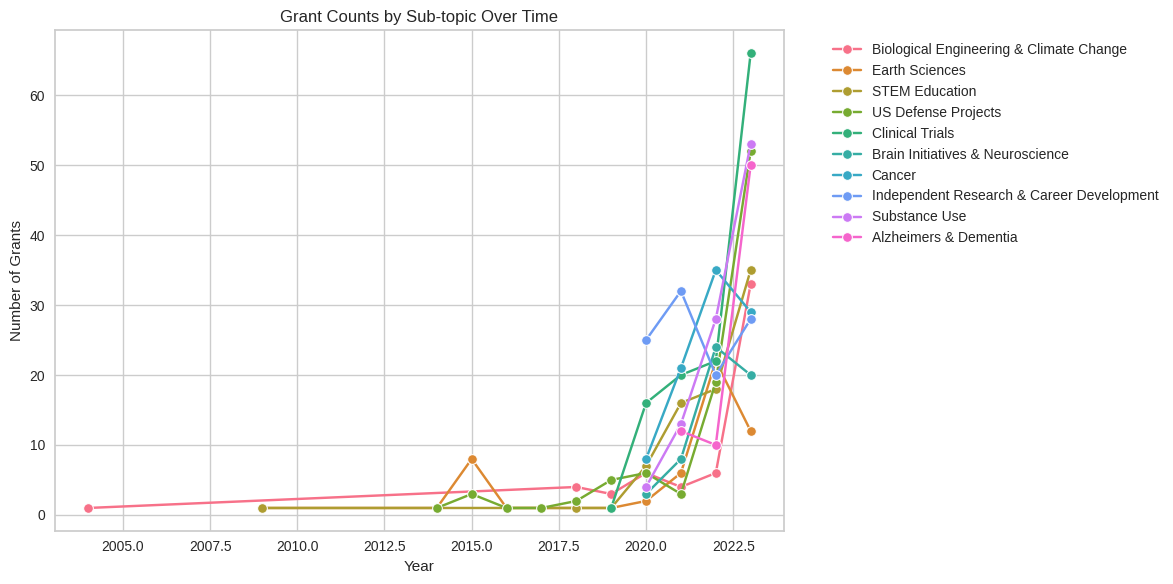

In [307]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=time_counts,
    x='posted_year',
    y='grant_count',
    hue='sub_topic',
    marker='o'
)

plt.title("Grant Counts by Sub-topic Over Time")
plt.ylabel("Number of Grants")
plt.xlabel("Year")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


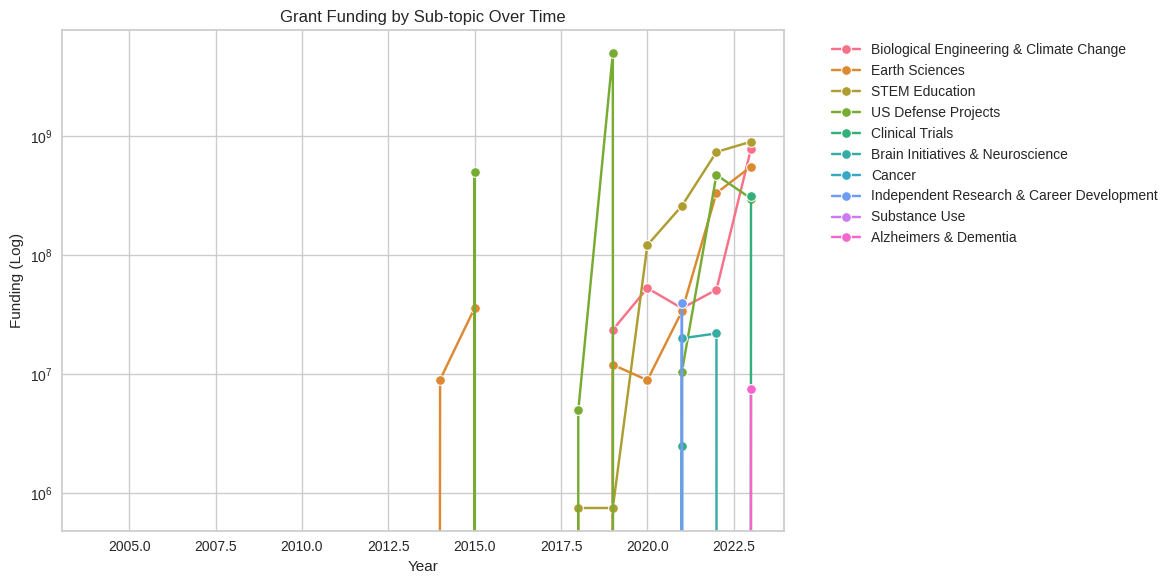

In [310]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=time_funding,
    x='posted_year',
    y='estimated_total_program_funding',
    hue='sub_topic',
    marker='o'
)

plt.title("Grant Funding by Sub-topic Over Time")
plt.ylabel("Funding (Log)")
plt.xlabel("Year")
plt.yscale('log')
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


## Widget Removal

In [311]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [315]:
!pip install nbformat

import nbformat

notebook_path = '/content/drive/MyDrive/MSBA Spring 2026/820 ML Group Project/M3 Work/Notebooks/Maggie_Croghan_M3.ipynb'  # change to your filename

nb = nbformat.read(notebook_path, as_version=4)

# Remove notebook-level widget metadata
nb.metadata.pop("widgets", None)

# Remove widget outputs from each cell
for cell in nb.cells:
    if "outputs" in cell:
        new_outputs = []
        for output in cell["outputs"]:
            # Remove widget view outputs
            if output.get("data", {}).get("application/vnd.jupyter.widget-view+json"):
                continue
            # Remove widget state outputs
            if output.get("data", {}).get("application/vnd.jupyter.widget-state+json"):
                continue
            new_outputs.append(output)
        cell["outputs"] = new_outputs

nbformat.write(nb, notebook_path)

print("All widget state removed successfully.")


All widget state removed successfully.
